### **DC demand profiles to understand what we work with**

In [1]:
import pandas as pd
import pandas as pd
import pypsa
import numpy as np
import xarray as xr
from pathlib import Path
import sys
from itertools import permutations
from typing import Optional, Dict, Any
df = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
df.head()

,cleansed_voltage_level,anonymised_data_centre_name,dc_type,local_timestamp,utc_timestamp,hh_utilisation_ratio
0,High Voltage Import,Data Centre #70,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.033600
1,Low Voltage Import,Data Centre #72,Enterprise,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.000000
2,Low Voltage Import,Data Centre #73,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.127279
3,Low Voltage Import,Data Centre #77,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.321519
4,Low Voltage Import,Data Centre #78,Co-located,2025-10-14T22:00:00+01:00,2025-10-14T21:00:00,0.501500


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5390364 entries, 0 to 5390363
Data columns (total 6 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   cleansed_voltage_level       object 
 1   anonymised_data_centre_name  object 
 2   dc_type                      object 
 3   local_timestamp              object 
 4   utc_timestamp                object 
 5   hh_utilisation_ratio         float64
dtypes: float64(1), object(5)
memory usage: 246.8+ MB


In [3]:
df.describe()

,hh_utilisation_ratio
count,5.390364e+06
mean,2.138716e-01
std,2.078744e-01
min,0.000000e+00
25%,4.000000e-02
50%,1.860750e-01
75%,3.292453e-01
max,3.991985e+00


In [4]:
df.groupby('anonymised_data_centre_name')['cleansed_voltage_level'].value_counts(ascending=False)

anonymised_data_centre_name  cleansed_voltage_level   
Data Centre #1               Extra-High Voltage Import    57598
Data Centre #10              High Voltage Import          57550
Data Centre #11              High Voltage Import          57694
Data Centre #12              High Voltage Import          57694
Data Centre #13              High Voltage Import          57694
                                                          ...  
Data Centre #92              Low Voltage Import           57646
Data Centre #93              Low Voltage Import           33312
Data Centre #94              Low Voltage Import           25726
Data Centre #95              Low Voltage Import           57646
Data Centre #96              Extra-High Voltage Import    57454
Name: count, Length: 96, dtype: int64

In [5]:
VAL = "hh_utilisation_ratio"
DC = "anonymised_data_centre_name"
TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TS = "utc_timestamp"
 
# order voltage levels low->high so plots read sensibly
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]

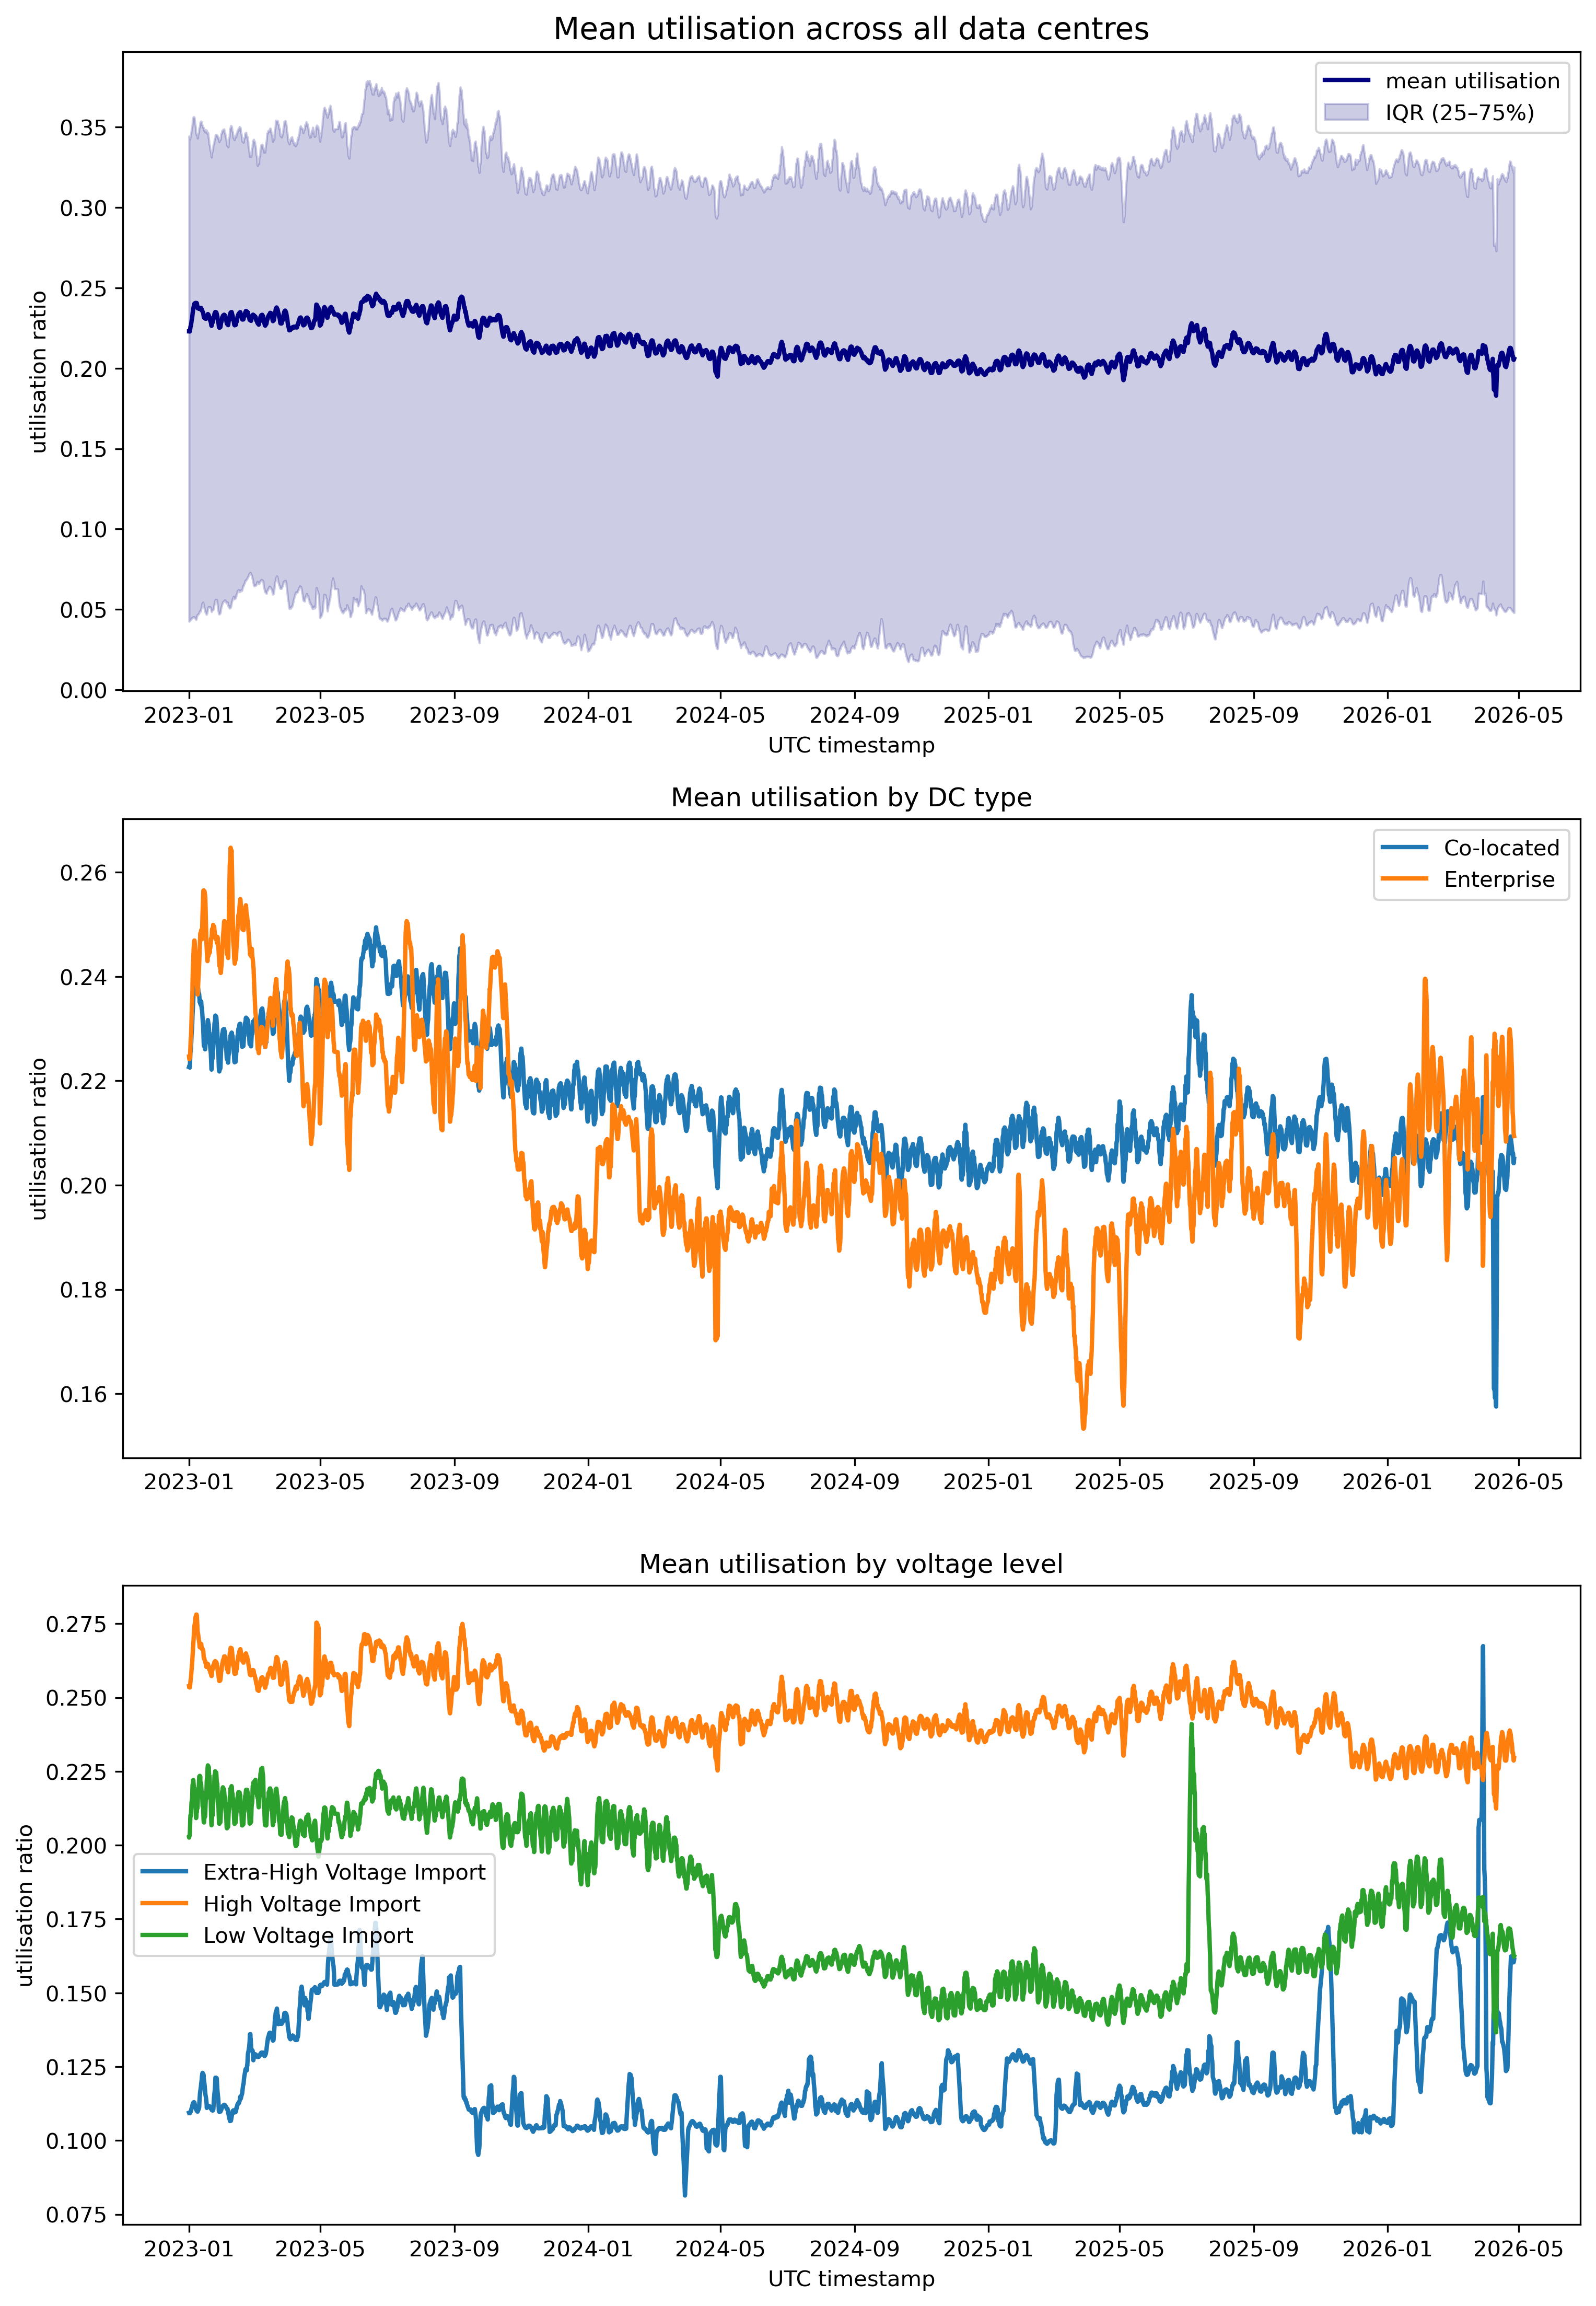

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

df[VAL] = pd.to_numeric(df[VAL], errors="coerce")
df[TS] = pd.to_datetime(df[TS], errors="coerce")

WINDOW = 150   # number of half-hour steps to average over

fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False,dpi=300)

g = df.groupby(TS)[VAL]
mean = g.mean().rolling(WINDOW, center=True, min_periods=1).mean()
lo   = g.quantile(0.25).rolling(WINDOW, center=True, min_periods=1).mean()
hi   = g.quantile(0.75).rolling(WINDOW, center=True, min_periods=1).mean()

axes[0].plot(mean.index, mean.values, color="navy", lw=2, label=f"mean utilisation")
axes[0].fill_between(mean.index, lo, hi, alpha=0.2, color="navy", label="IQR (25–75%)")
axes[0].set_title("Mean utilisation across all data centres",fontsize = 14)
axes[0].set_ylabel("utilisation ratio")
axes[0].set_xlabel("UTC timestamp")
axes[0].legend()

for label, sub in df.groupby(TYPE):
    m = sub.groupby(TS)[VAL].mean().rolling(WINDOW, center=True, min_periods=1).mean()
    axes[1].plot(m.index, m.values, lw=2, label=label)
axes[1].set_title("Mean utilisation by DC type")
axes[1].set_ylabel("utilisation ratio")
axes[1].legend()

for label, sub in df.groupby(VOLT, observed=True):
    m = sub.groupby(TS)[VAL].mean().rolling(WINDOW, center=True, min_periods=1).mean()
    axes[2].plot(m.index, m.values, lw=2, label=label)
axes[2].set_title("Mean utilisation by voltage level")
axes[2].set_ylabel("utilisation ratio")
axes[2].set_xlabel("UTC timestamp")
axes[2].legend()

plt.show()

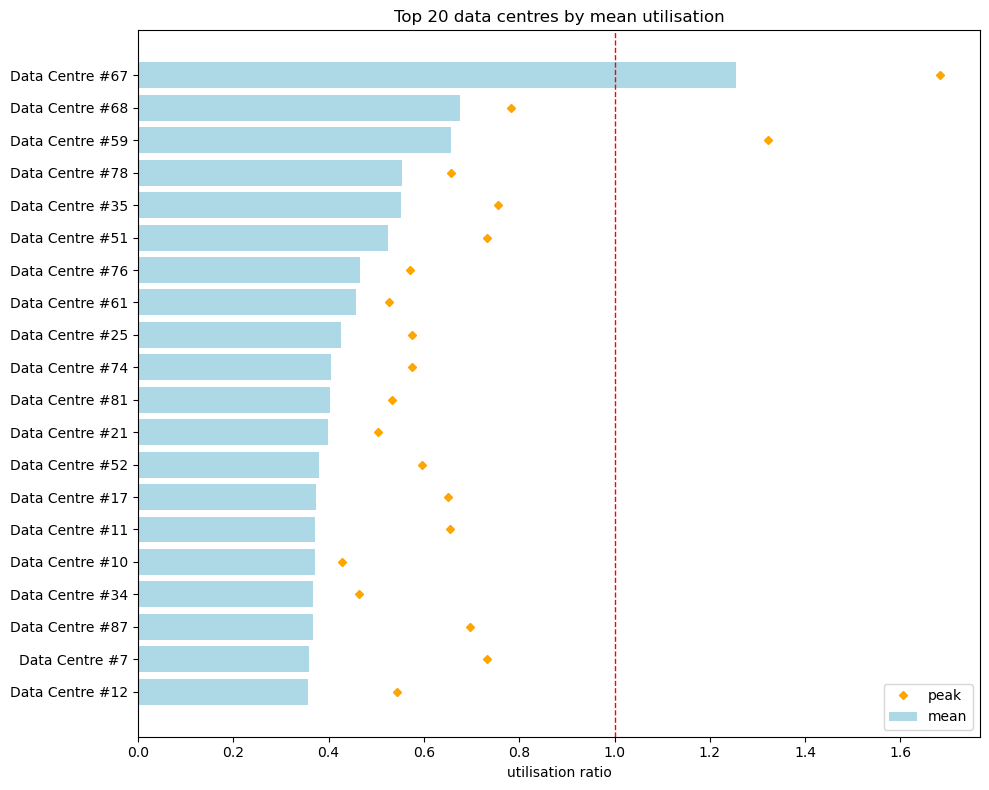

In [7]:
stats = (df.groupby(DC)[VAL]
            .agg(mean="mean", peak="max", n="count")
            .sort_values("mean", ascending=False))

top_n = 20
top = stats.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(top))

ax.barh(y, top["mean"], color="lightblue", label="mean")
ax.plot(top["peak"], y, "D", color="orange", ms=4, label="peak")
ax.set_yticks(list(y))
ax.set_yticklabels(top.index)
ax.axvline(1.0, color="red", ls="--", lw=1)

ax.set_title(f"Top {top_n} data centres by mean utilisation")
ax.set_xlabel("utilisation ratio")
ax.legend()

fig.tight_layout()
plt.show()

utc_timestamp
0 days 00:30:00    57784
1 days 00:30:00        3
3 days 00:30:00        1
2 days 00:30:00        1
Name: count, dtype: int64


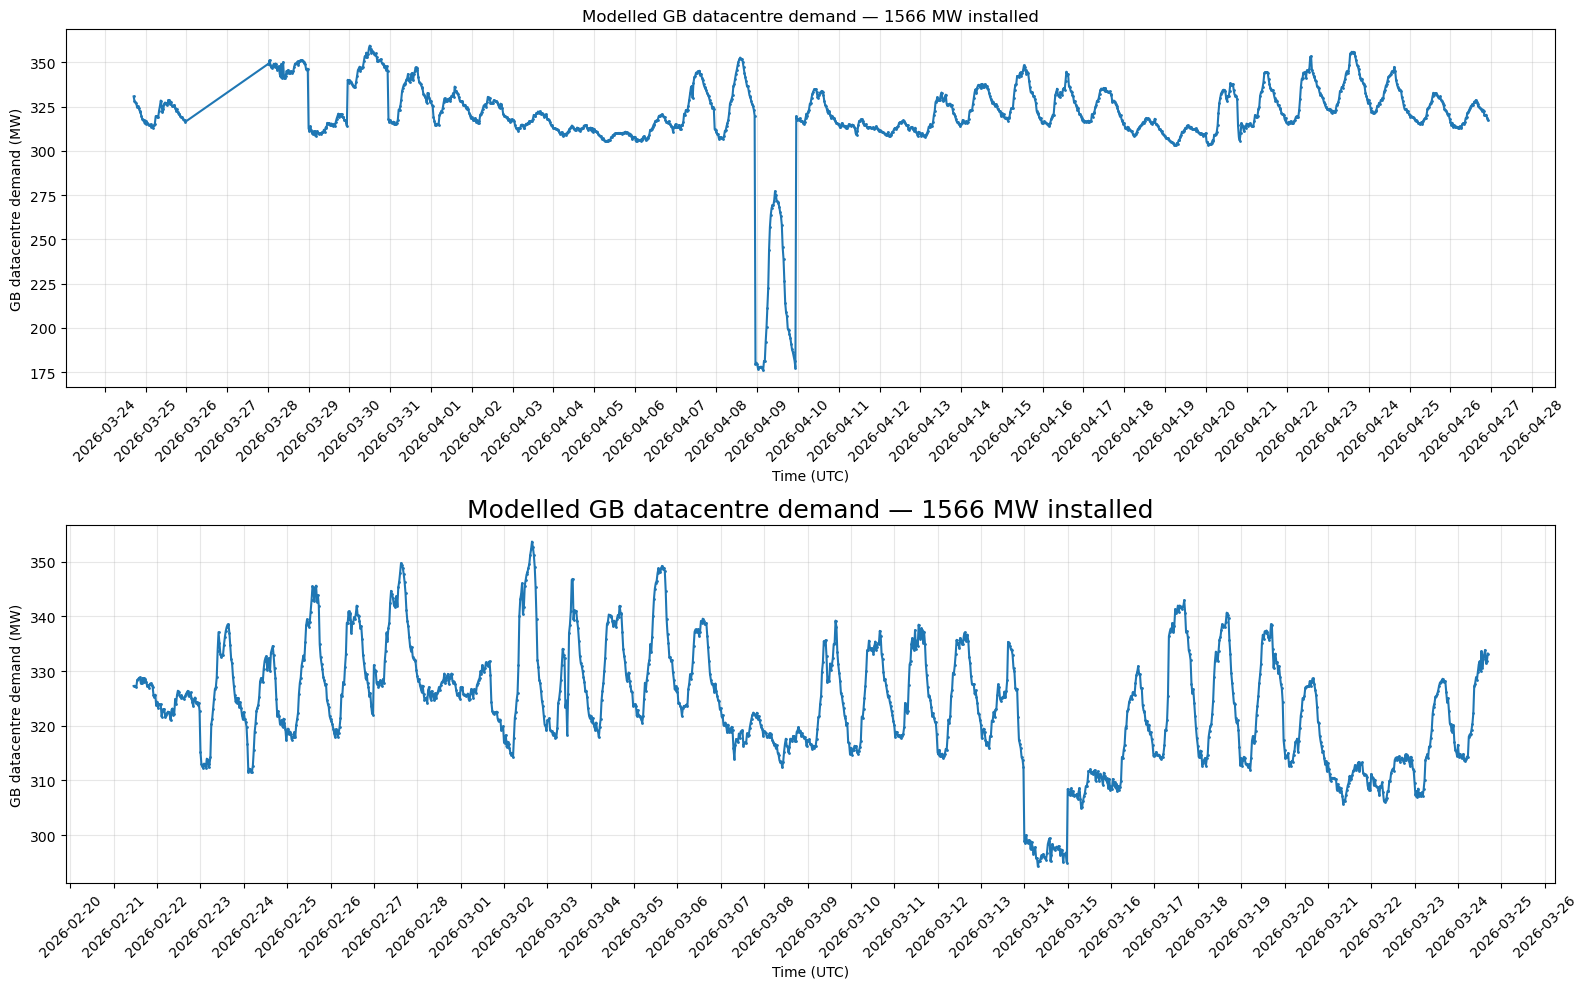

In [8]:
import matplotlib.dates as mdates

df = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")

# renaming columns for ease of use
UTIL = "hh_utilisation_ratio"
DC_NAME = "anonymised_data_centre_name"
DC_TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TIME = "utc_timestamp"
# ordering voltage -> low to extra high
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
df[TIME] = pd.to_datetime(df[TIME], utc=True)

demand_profile_per_dt = df.groupby(TIME)[UTIL].mean().sort_index()
print(demand_profile_per_dt.index.to_series().diff().value_counts())
# https://www.gov.uk/government/publications/estimate-of-data-centre-capacity-great-britain-2024/estimate-of-data-centre-capacity-great-britain-2024
TOTAL_DC_CAPACITY = 1566 #in MW; 1.6 GW is the current GB capacity

num_modelled_dc = 3
num_dc = df[DC_NAME].nunique()

dc_demand_mw = TOTAL_DC_CAPACITY * demand_profile_per_dt
dc_demand_mw_per_centre = dc_demand_mw / num_modelled_dc

n =1500
dc_demand_mw_top_1500 = dc_demand_mw.iloc[-n:-1]        # points 0–1499
dc_demand_mw_top_3000 = dc_demand_mw.iloc[-2*n:-n]      # points 1500–2999


fig, ax = plt.subplots(2,1, figsize=(16, 10))
ax[0].plot(dc_demand_mw_top_1500.index, dc_demand_mw_top_1500.values, 
        marker="o", 
        markersize=1)
ax[0].set_xlabel("Time (UTC)")
ax[0].set_ylabel("GB datacentre demand (MW)")
ax[0].set_title(f"Modelled GB datacentre demand — {TOTAL_DC_CAPACITY} MW installed")
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis="x", labelrotation=45)

ax[0].xaxis.set_major_locator(mdates.DayLocator())
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))



ax[1].plot(dc_demand_mw_top_3000.index, dc_demand_mw_top_3000.values, 
        marker="o", 
        markersize=1)
ax[1].set_xlabel("Time (UTC)")
ax[1].set_ylabel("GB datacentre demand (MW)")
ax[1].set_title(f"Modelled GB datacentre demand — {TOTAL_DC_CAPACITY} MW installed",fontsize=18)
ax[1].grid(True, alpha=0.3)
ax[1].tick_params(axis="x", labelrotation=45)

ax[1].xaxis.set_major_locator(mdates.DayLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.tight_layout()
plt.show()


---
---
## <span style=color:yellow> **MARTA'S IMPLEMENTATION**
---
---

#### **Import libraries required**

In [9]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import plotly
import seaborn as sb
import matplotlib.pyplot as plt


### <span style=color:pink> **Get data(frames) needed for the project**

#### **Data centre demand profiles**

In [10]:
df_dc_demand_profile = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
# df_dc_demand_profile.head()
# assigning df column names to something shorter for ease
UTIL = "hh_utilisation_ratio"
DC_NAME = "anonymised_data_centre_name"
DC_TYPE = "dc_type"
VOLT = "cleansed_voltage_level"
TIME = "utc_timestamp"
# ordering voltage -> low to extra-high
VOLT_ORDER = ["Low Voltage Import", "High Voltage Import", "Extra-High Voltage Import"]
# convert tot date/time
df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], utc=True)
df_dc_demand_profile

,cleansed_voltage_level,anonymised_data_centre_name,dc_type,local_timestamp,utc_timestamp,hh_utilisation_ratio
0,High Voltage Import,Data Centre #70,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.033600
1,Low Voltage Import,Data Centre #72,Enterprise,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.000000
2,Low Voltage Import,Data Centre #73,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.127279
3,Low Voltage Import,Data Centre #77,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.321519
4,Low Voltage Import,Data Centre #78,Co-located,2025-10-14T22:00:00+01:00,2025-10-14 21:00:00+00:00,0.501500
...,...,...,...,...,...,...
5390359,Extra-High Voltage Import,Data Centre #32,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.000000
5390360,High Voltage Import,Data Centre #33,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.053160
5390361,High Voltage Import,Data Centre #36,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.183600
5390362,High Voltage Import,Data Centre #4,Co-located,2026-02-18T06:00:00+00:00,2026-02-18 06:00:00+00:00,0.242749


#### **Population data**

In [11]:
# https://www.worldometers.info/population/largest-cities-in-uk/
df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")

df_population = df_population.drop(columns=['Global Rank'])
df_population.head()

,Rank,Urban Area,Population Estimate (2025),1 Year Change (over 2024),Land Area (Km2),Density (P/Km2),Projections (2030),Projections (2050),Easting,Northing
0,1,London,"10,416,420",0.82%,"1,646","6,328","10,766,831","11,868,905",530029,180380
1,2,Birmingham,"2,631,757",0.54%,671,"3,922","2,689,574","2,810,468",407540,287592
2,3,Manchester,"2,535,427",0.38%,741,"3,422","2,567,727","2,638,194",383997,398258
3,4,Liverpool,"1,227,470",0.53%,369,"3,326","1,241,135","1,254,523",334179,390634
4,5,Leeds,"1,065,607",0.45%,323,"3,299","1,086,815","1,109,261",429796,433927


#### **FES data**

In [12]:
url = ("https://api.neso.energy/dataset/2c15c755-d8fe-4229-9169-3b6dd7c88fec/"
       "resource/300c07b9-baeb-4411-bc40-987cbb4aec0b/download/fes2025_ed1_v006.csv")
df_neso_energy_demand = pd.read_csv(url)

# print(df_neso_energy_demand.head(20))

df_fes_filtered = df_neso_energy_demand[
    (df_neso_energy_demand['Data item'] == 'Data Centre Demand') |
    (df_neso_energy_demand['Data item'] == 'GBFES System Demand: Total')
]
df_fes_filtered

,Aggregation Level,Data item,Unit,Pathway,Fuel,Peak/ Annual/ Minimum,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,1,GBFES System Demand: Total,GWh,Hydrogen Evolution,Electricity,Annual [Fiscal],286780.0,289650.0,293394.0,297512.0,...,629181.0,658165.0,691892.0,720585.0,732957.0,748081.0,770705.0,778236.0,795993.0,797120.0
1,1,GBFES System Demand: Total,GWh,Electric Engagement,Electricity,Annual [Fiscal],286780.0,289650.0,291698.0,296073.0,...,644531.0,672190.0,694708.0,709671.0,724440.0,737930.0,752313.0,766439.0,776227.0,784736.0
2,1,GBFES System Demand: Total,GWh,Falling Behind,Electricity,Annual [Fiscal],286780.0,289650.0,295231.0,298512.0,...,450011.0,464557.0,477519.0,490691.0,504316.0,516137.0,526834.0,537853.0,548276.0,558750.0
3,1,GBFES System Demand: Total,GWh,Holistic Transition,Electricity,Annual [Fiscal],286780.0,289650.0,290891.0,294991.0,...,582761.0,602352.0,621073.0,635458.0,654296.0,670284.0,681236.0,691034.0,700725.0,705223.0
4,1,GBFES System Demand: Total,GWh,Ten Year Forecast,Electricity,Annual [Fiscal],286780.0,289650.0,292075.0,295108.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,5,Data Centre Demand,GWh,Hydrogen Evolution,Electricity,Annual [Fiscal],7400.0,7538.0,8651.0,9735.0,...,39705.0,41216.0,42709.0,44132.0,45430.0,46664.0,47856.0,49012.0,50139.0,51242.0
121,5,Data Centre Demand,GWh,Electric Engagement,Electricity,Annual [Fiscal],7400.0,7565.0,9343.0,10912.0,...,56831.0,58855.0,60678.0,62329.0,63884.0,65356.0,66757.0,68098.0,69352.0,70562.0
122,5,Data Centre Demand,GWh,Falling Behind,Electricity,Annual [Fiscal],7400.0,7518.0,8014.0,8400.0,...,24696.0,25407.0,26070.0,26704.0,27357.0,27986.0,28594.0,29184.0,29766.0,30334.0
123,5,Data Centre Demand,GWh,Holistic Transition,Electricity,Annual [Fiscal],7400.0,7565.0,9259.0,10864.0,...,51867.0,53796.0,55559.0,57165.0,58687.0,60136.0,61519.0,62845.0,64101.0,65317.0
124,5,Data Centre Demand,GWh,Ten Year Forecast,Electricity,Annual [Fiscal],7400.0,7738.0,8129.0,8929.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Create sub-functions to complete easy tasks within main functions**

##### ✅ **Fully Working Functions:**

In [13]:
def _nearest_bus(base_network: pypsa.Network, easting, northing, nearest_n_buses = False):
    '''
    This function finds the nearest bus for the specified location (easting / northing).

    Args:
        - base network: the pypsa baseline network to add data centres to
        - easting and northing of the preferred location
    
    Returns:
        - bus that has to closest to the specified location
    '''

    # get AC buses only
    ac_bus = base_network.buses[(base_network.buses.carrier == "AC") & 
                                (~base_network.buses.index.str.contains("HVDC|external", case=False))
                                ]

    # find the distance between selected point and the AC buses
    distance = np.sqrt((ac_bus.x-easting)**2 + (ac_bus.y-northing)**2)
    # select the one with minimum distance
    nearest_bus = distance.idxmin()
    if nearest_n_buses:
        return distance.sort_values(ascending = True)
    
    return nearest_bus

def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1) -> float:
    '''
    This function takes the snapshot of selected time and converts that into hours.

    Args:
        - index: 
        - default: default state in case the number of hours 
    Returns:
        - 
    '''
    if index is None or len(index) < 2:
        return default
    delta_hours = (index[1] - index[0]).total_seconds() / 3600.0
    return delta_hours if delta_hours > 0 else default

def _get_dc_demand_profile(return_mean_utilisation = False):
    '''
    This function returns the demand profile (per half-hourly timestep), based on the UKPN data.
    Returns:
        - demand_profile_per_dt: returns the full demand profile, averaged across 94 data centres in the UKPN region, 
        for each half-hour time-step 01-01-2023–26-04-2026.
        - mean utilisation: OPTIONAL, instead of returning the demand profile for each timestep, returns the overall mean utilisation value.
    '''
    df_dc_demand_profile = pd.read_csv("../data/data_centres/ukpn-data-centre-demand-profiles.csv")
  
    # assigning df column names to something shorter for ease
    UTIL = "hh_utilisation_ratio"
    TIME = "utc_timestamp"
    
    # convert to date/time
    df_dc_demand_profile[UTIL] = pd.to_numeric(df_dc_demand_profile[UTIL], errors="coerce")
    df_dc_demand_profile[TIME] = pd.to_datetime(df_dc_demand_profile[TIME], errors="coerce", utc=True)

    demand_profile_per_dt = df_dc_demand_profile.groupby(TIME)[UTIL].mean().sort_index()

    if return_mean_utilisation:
        mean = demand_profile_per_dt.mean()
        return mean

    return demand_profile_per_dt

def _get_total_dc_demand_FES_gw(year: int, scenario: str, return_GWh = False, mean_utilisation = 0.55):
    '''
    This function takes the total load demand - wether it's from historic data or Future Energy Scenario (FES),
    and calculates the DC demand as a fraction of the total demand.

    Args:
        - total_gwh: GB's total load demand in GWh
        - fraction: assumed % of the total demand that data centres account for (0.9–2%, predicted). Default value: 2% = 0.02
    Returns:
        - total_dc_gw: the total capacity of data centres, as predicted by FES, in GW
        - total_dc_gwh: 
    '''
    # list available scenarios
    scenario_list = ['Hydrogen Evolution', 'Holistic Transition', 'Falling Behind', 'Electric Engagement']
    if scenario not in scenario_list:
        raise NameError("Wrong scenario name. Available scenarios:", scenario_list)
    
    elif year <= 2022 or year > 2050:
        raise ValueError("This is a module for Future Scenarios. Enter year > 2022, up to 2050.")
    else:
        df_fes = pd.read_csv("../data/data_centres/fes2025_ed1_v006.csv")

        # take the data from column matching year choice & row = desired scenario for data centre demand
        total_dc_gwh = float(df_fes[str(year)][
            (df_fes['Data item'] == 'Data Centre Demand') &
            (df_fes['Pathway'] == scenario)].iloc[0])
        total_dc_gw = total_dc_gwh / 8760 / mean_utilisation

    if return_GWh:
        return total_dc_gwh

    return total_dc_gw


- [x] Check how to get mean utilisation for say the past year and 
- [x] compare with the overall utilisation (especting higher value)

In [14]:
# import pandas as pd
# df = _get_dc_demand_profile()  

# mean_2023 = df.loc["2023-01-01":"2023-12-31"].mean()
# mean_last_year = df.loc["2025-04-27":"2026-04-26"].mean()
# print(mean_2023)
# print(mean_last_year)

In [15]:
def _convert_DC_demand_profile_to_GWh(total_dc_capacity_gw: float):
    '''
    This function converts the peak data centre capacity (GW) to the demand time series (GWh) and total demand (GWh).
    Args:
        - total_dc_capacity_gw: Peak data centre capacity (GW)
    Returns:
        - dc_time_series_demand_gwh: demand in GWh as half-hourly time series
        - total_dc_demand_gwh: total data centre demand over selected period of time
    '''

    # get the half-hourly demand profile
    demand_profile_per_dt = _get_dc_demand_profile()
    mean_utilisation = demand_profile_per_dt.mean()

    dc_demand_gw = total_dc_capacity_gw * demand_profile_per_dt

    timestep_hours = _get_timestep_hours(dc_demand_gw.index)
    dc_time_series_demand_gwh = dc_demand_gw * timestep_hours
    total_dc_demand_gwh = total_dc_capacity_gw  * mean_utilisation * 8760

    return dc_time_series_demand_gwh, total_dc_demand_gwh

def _get_total_dc_demand_MANUAL_gw(year: int, dc_prediction_2030_gw = 6.0):
    '''
    This function predicts a compound increase in DC capacity, based on the prediction made for the 
    2025 -> 2030 increase (1.6 GW -> 6.0 GW).
    This load will be added on top of the overall FES-predicted load / demand.
    Args:
        - year: a year which you want to predict the capacity for
        - dc_prediciton_20230_gw: used to calculate rate; assumed to be the current 6.0 GW by default, 
            but can be set to a more pessimistic (4.0 GW) or optimistic (8.0 GW)
            scenario to affect the rate and predict pessimistic/optmistic future scenarios overall.
    Returns:
        - total_dc_gw: the total capacity of the data centres
    '''
    
    # 6.0 (GW planned for 2030) = 1.6 (GW as of 2025) * (1+rate)**5  -> rate = (6.0/1.6)**1/5 - 1
    rate = (dc_prediction_2030_gw / 1.6) ** (1/5) - 1 
    total_dc_gw = 1.6 * (1+rate)**(year-2025)

    return total_dc_gw

#### **TESTS - get demand profile**

In [16]:
# _get_dc_demand_profile(return_mean_utilisation=True)

#### **TESTS - Manual demand vs FES**

In [17]:
# test_demand = _get_total_dc_demand_MANUAL_gw(year = 2028, dc_prediction_2030_gw = 12.0)
# _, manual_gwh = _convert_DC_demand_profile_to_GWh(total_dc_capacity_gw = test_demand)
# print(test_demand)
# print(manual_gwh)


In [18]:
# idx = _get_dc_demand_profile().index
# print(idx.min(), idx.max(), (idx.max()-idx.min()).days)

In [19]:
# test = _get_total_dc_demand_FES_gw(year = 2028, scenario = 'Falling Behind', return_GWh = False)
# print(test)
# gwh = _get_total_dc_demand_FES_gw(year = 2028, scenario = 'Falling Behind', return_GWh = True)
# print(gwh)

---
---
## <span style="color:yellow">       **Create functions for the main workflow** </span>
---
---

#### **TESTS - network**

In [20]:
# _nearest_bus(base_network = zonal, easting=290000, northing=870000, nearest_n_buses = True)

#### **Allocation - north**

In [21]:
import pandas as pd
import pypsa
import logging
import numpy as np
import xarray as xr
from pathlib import Path
import sys
from typing import Optional, Dict, Any

def allocate_north_scotland(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float = 300) -> pd.Series:
    '''
    Allocation model placing ALL specified capacity in the North of Scotland as close to 290000, 870000 point (easting, northing) as possible.
    The model selectes n closest buses to place DCs on, where n is the total number of DCs.

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''

    # number of full-capacity data centres that fit into the total capcity specified
    num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))
    # total number of data centres added - +1 if total caapcity not divisible by single_dc_mw
    new_dc_mw = round(total_dc_gw * 1000 / num_dc, 2)

    # the list of available buses closest to the selected point in north of scotland, 
    # sorted by distance (closest -> furthest)
    bus_list = _nearest_bus(base_network, 290000, 870000, nearest_n_buses=True)
    bus_list = bus_list.head(num_dc)  # keeping only

    # set initial state of the dc capacity on buses - 0.0
    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    dc_allocation.loc[bus_list.index[:num_dc]] = new_dc_mw # assign DC capacities only to the closest n buses
    
    print(f"Allocated {dc_allocation.sum():.1f} GW in the north of Scotland ONLY ({num_dc} DCs of {new_dc_mw} MW).")
    
    return dc_allocation



#### **TESTS - north**

In [22]:
# allocate_north_scotland(total_dc_gw = 1.9, base_network = zonal, logger = logging.Logger)

#### **Allocation - current split**

In [23]:
def allocate_current_split_scaled(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float=300) -> pd.Series:
    '''
    This scenario takes into account the current capacity split across the country and keeps the 
    exact ratio of the capacities across regions: 
        - Scotland + North East + North West = 99 MW; 
        - Yorkshire and the Humber + Midlands + Wales = 194; 
        - London = 1,048; 
        - South West + South East + East = 225.

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''
    # values based on: 
    # https://www.gov.uk/government/publications/estimate-of-data-centre-capacity-great-britain-2024/estimate-of-data-centre-capacity-great-britain-2024
    total_current_mw = 1566
    scotland_fraction = 99 / total_current_mw
    midlands_fraction = 194 / total_current_mw
    london_fraction = 1048 / total_current_mw
    england_fraction = 225 / total_current_mw

    # create lists of fractions, eastings and northings (same order)
    fractions = [scotland_fraction, midlands_fraction, london_fraction, england_fraction]
    eastings = [290000, 430000, 530000, 450000]
    northings = [870000, 400000, 180000, 170000]

    # initialise for the loop
    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    total_num_dc = 0
    dc_mw = []

    for i, fraction in enumerate(fractions):
        current_mw = total_dc_gw * 1000 * fraction

        if current_mw > single_dc_mw:
            num_dc = int(np.floor(current_mw / single_dc_mw ))
            new_dc_mw = round(current_mw / num_dc, 2)
        else: 
            new_dc_mw = round(current_mw, 2)
            num_dc = 1
        
        bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
        bus_list = bus_list.head(num_dc)

        already_used = (dc_allocation.loc[bus_list.index[:num_dc]] != 0.0).any()
        if already_used:
            print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
        dc_allocation.loc[bus_list.index[:num_dc]] += new_dc_mw # assign DC capacities only to the closest n buses
        
        total_num_dc =+ num_dc
        dc_mw.append(new_dc_mw)
        print(f"Allocated {new_dc_mw * num_dc:.2f} MW ({num_dc} DC(s) of {new_dc_mw} MW).")
    
    print(f"Allocated {dc_allocation.sum():.2f} MW across the  ({total_num_dc} DCs of {dc_mw} MW).")
    
    return dc_allocation

#### **TESTS - current split**

In [24]:
# _get_total_dc_demand_FES_gw(year = 2028, scenario='Falling Behind', mean_utilisation=_get_dc_demand_profile(return_mean_utilisation=True))

In [25]:
# allocate_current_split_scaled(total_dc_gw = _get_total_dc_demand_FES(year = 2028, scenario='Holistic Transition'), base_network = clustered, logger = logging.Logger, single_dc_mw=800)

#### **Allocation - population**

In [26]:
def allocate_population_density_weighted(total_dc_gw: float, base_network: pypsa.Network, logger, single_dc_mw: float = 300) -> pd.Series:
    '''
    This scenario takes into account the highest population density points across the UK 
    and places the data centre capacities ~proportionally at those locations:
        - London 6 first data centres
        - Birmingham 7th & 8th DC
        - Manchester 9th & 10th DC
        - remaining DCs 1 per city

    Args:
        - total_dc_gw: the total NEW data centre capacity
        - base_network: the base pypsa network, data centres (amongst other components) are being added on to
        - single_dc_mw: assumed size of a single data centre, in MW. Data centres won't have exactly this capcity, 
        but rather this + the evenly distributed remaining capacity after calculating the total number of DCs - rounding down the total capacity / single_dc_mw
    Returns:
        - dc_allocation: the allocated DC load per bus
    '''
    # https://www.worldometers.info/population/largest-cities-in-uk/
    df_population = pd.read_csv("../data/data_centres/uk_largest_cities.csv")
    df_population = df_population.drop(columns=['Global Rank'])
  
    eastings = df_population["Easting"].tolist()
    northings = df_population["Northing"].tolist()

    dc_allocation = pd.Series(0.0, index = base_network.buses.index)
    total_num_dc = int(np.floor(total_dc_gw * 1000 / single_dc_mw))
    new_dc_mw = round(total_dc_gw * 1000/total_num_dc, 2)
    print(f"Allocated {dc_allocation.sum():.2f} MW population-weighted across the ({total_num_dc} DCs of {new_dc_mw} MW).")

    if total_num_dc <= 6:
        print('6')
        # first 6 to be placed near London
        bus_list = _nearest_bus(base_network, eastings[0], northings[0], nearest_n_buses=True)
        bus_list = bus_list.head(total_num_dc)
        dc_allocation.loc[bus_list.index[:total_num_dc]] += new_dc_mw

    elif total_num_dc <= 8:
        # 6 in London + 2 in Birmingham
        print('8')
        for i in range (0,2):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(total_num_dc)

            already_used = (dc_allocation.loc[bus_list.index[:total_num_dc]] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index[:num_dc]] += new_dc_mw

    elif total_num_dc <= 10:
        # 6 in London + 2 in Birmingham + 2 in Manchester
        print('10')
        for i in range (0,3):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(total_num_dc)

            already_used = (dc_allocation.loc[bus_list.index[:total_num_dc]] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index[:num_dc]] += new_dc_mw

    else:
        # 6 in London + 2 in Birmingham + 2 in Manchester + rest, as many as there are, one DC in each city
        for i in range (0,total_num_dc):
            bus_list = _nearest_bus(base_network, eastings[i], northings[i], nearest_n_buses=True)
            bus_list = bus_list.head(total_num_dc)

            already_used = (dc_allocation.loc[bus_list.index[:total_num_dc]] != 0.0).any()
            if already_used:
                print(f"Warning: bus overlap detected in region {i}, adding to existing allocation")
            dc_allocation.loc[bus_list.index[:total_num_dc]] += new_dc_mw

    return dc_allocation

#### **TESTS - population**

In [27]:
# allocate_population_density_weighted(total_dc_gw = _get_total_dc_demand_FES(year = 2028, scenario='Holistic Transition', mean_utilisation=0.8), base_network = zonal, logger = logging.Logger, single_dc_mw=300)

#### **~~Create a 3-year cycle for demand profiles~~**
#### **Stick to a weekly pattern**

In [28]:
def _build_dc_reference_profile(start="2023-01-01", end="2025-12-31") -> pd.Series:
    '''
    Builds a representative weekly cycle from 3 years of UKPN data,
    averaged by (dayofweek, hour, minute) — the monthly/seasonal component
    was dropped due to insignificant (+/- 1%) seasonal changes.
    
    Current weekly changes are very minor as well. Hopwever, these can be expected to get
    more drastic as the demand increases over the upcoming years.
    Args:
        - start: start of the period (date) taken into account for averaging
        - end: end of the period (date) taken into account for averaging 
    '''
    # get the profile data between start & end
    profile = _get_dc_demand_profile().loc[start:end]
    # profile.index = profile.index.tz_localize(None)
    
    key = pd.MultiIndex.from_arrays([
        profile.index.dayofweek,   # 0=Mon -> 6=Sun
        profile.index.hour,
        profile.index.minute
    ], names=["dayofweek", "hour", "minute"])

    # build the reference weekly profile, based on the average values across the three years
    reference_profile = profile.groupby(key).mean()

    return reference_profile

def _get_dc_demand_profile_for_snapshots(snapshots: pd.DatetimeIndex,
                                          reference_profile: pd.Series = None) -> pd.Series:
    if reference_profile is None:
        reference_profile = _build_dc_reference_profile()

    keys = list(zip(snapshots.dayofweek, snapshots.hour, snapshots.minute))

    values = reference_profile.reindex(keys)

    if values.isna().any():
        raise ValueError("Unresolved gaps in weekly reference profile — "
                          "check source data covers all 7 weekdays at every half-hour.")

    return pd.Series(values.values, index=snapshots)

def _get_dc_demand_mw_timeseries(dc_allocation: pd.Series, base_network: pypsa.Network) -> pd.DataFrame:
    '''
    Function converting the demand profile into a half-hourly time series (in MW).
    Args:
        - dc_allocation: the final allocation of data centre capacity at each bus
        - base_network: the baseline network used for the simulation
    Returns:
        - dc_demand_timeseries_mw: the data centre demand time series
    '''
    demand_profile = _get_dc_demand_profile_for_snapshots(base_network.snapshots)

    if demand_profile.isna().any():
        raise ValueError("Unresolved gaps in cyclical DC profile — check reference build.")

    dc_demand_timeseries_mw = pd.DataFrame(
        {bus: demand_profile.values * capacity for bus, capacity in dc_allocation[dc_allocation > 0].items()},
        index=base_network.snapshots
    )

    return dc_demand_timeseries_mw

In [29]:
# _build_dc_reference_profile()

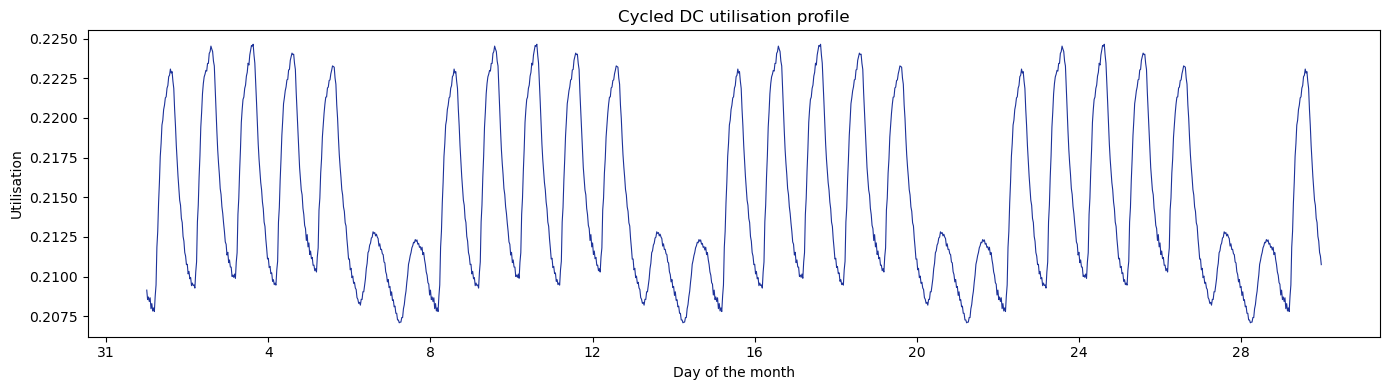

In [30]:
reference = _build_dc_reference_profile()

target = pd.date_range("2030-04-01", "2030-04-29 23:30", freq="30min", tz="UTC")
target_key = pd.MultiIndex.from_arrays(
    [target.dayofweek, target.hour, target.minute],
    names=["dayofweek", "hour", "minute"]
)
cycled = pd.Series(reference.reindex(target_key).values, index=target)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cycled.index, cycled.values, linewidth=0.8, color="#1D3299")

ax.set_title("Cycled DC utilisation profile")
ax.set_ylabel("Utilisation")
ax.set_xlabel("Day of the month")
ax.xaxis.get_offset_text().set_visible(False)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%-d'))
plt.tight_layout(); plt.show()

### **Checking for seasonal patters**

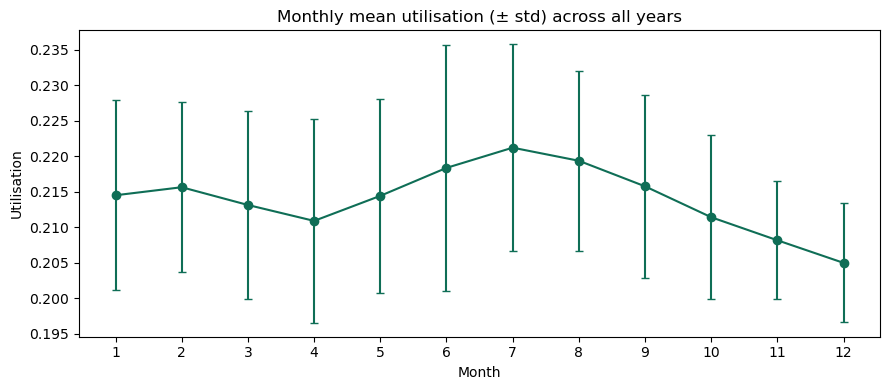

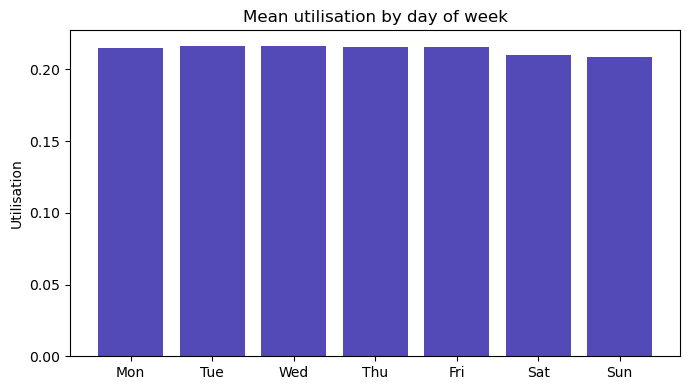

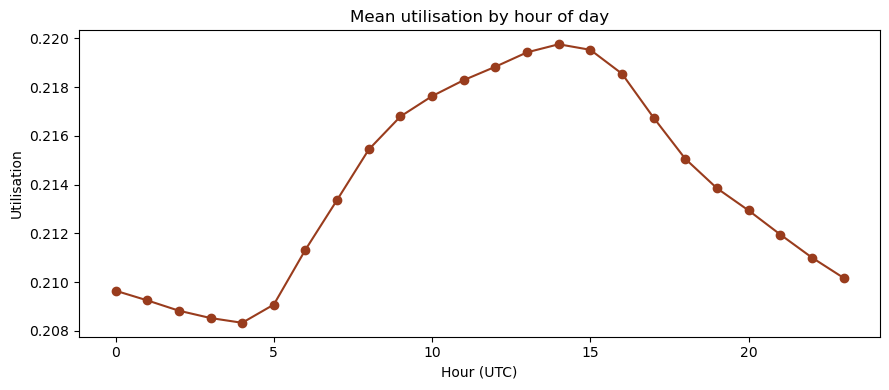

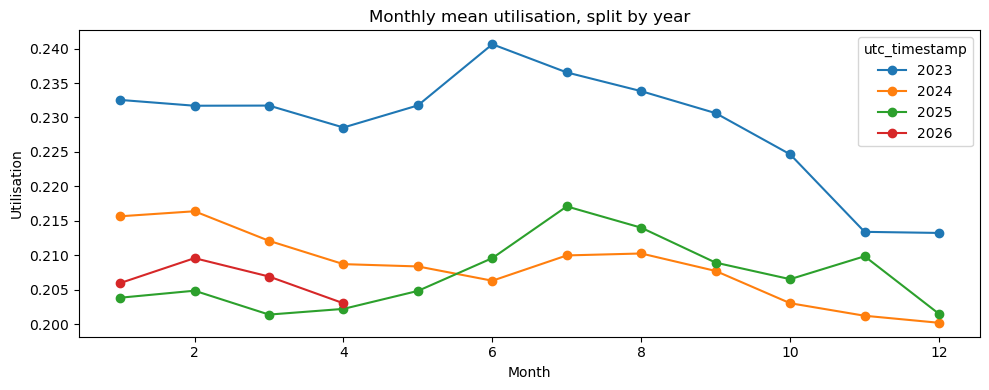

In [31]:
import matplotlib.pyplot as plt

fleet_profile = _get_dc_demand_profile()

monthly_mean = fleet_profile.groupby(fleet_profile.index.month).mean()
monthly_std = fleet_profile.groupby(fleet_profile.index.month).std()

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(monthly_mean.index, monthly_mean.values, yerr=monthly_std.values,
            fmt="-o", color="#0F6E56", capsize=3)
ax.set_xticks(range(1, 13))
ax.set_title("Monthly mean utilisation (± std) across all years")
ax.set_xlabel("Month"); ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

dow_mean = fleet_profile.groupby(fleet_profile.index.dayofweek).mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow_mean.values, color="#534AB7")
ax.set_title("Mean utilisation by day of week")
ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

hourly_mean = fleet_profile.groupby(fleet_profile.index.hour).mean()
fig, ax = plt.subplots(figsize=(9, 4))
hourly_mean.plot(ax=ax, marker="o", color="#993C1D")
ax.set_title("Mean utilisation by hour of day")
ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

by_year_month = fleet_profile.groupby([fleet_profile.index.year, fleet_profile.index.month]).mean().unstack(level=0)
fig, ax = plt.subplots(figsize=(10, 4))
by_year_month.plot(ax=ax, marker="o")
ax.set_title("Monthly mean utilisation, split by year")
ax.set_xlabel("Month"); ax.set_ylabel("Utilisation")
plt.tight_layout(); plt.show()

#### **Add DC as Load**

In [32]:
def add_dc_as_load(base_network: pypsa.Network,
                   buses: list,
                   dc_demand_mw: pd.DataFrame,
                   carrier: str = "Data Centre",
                   logger: Optional[logging.Logger] = None) -> pypsa.Network:
    '''
    Add data centres as simple Load components (no flexibility).

    Args:
        n: PyPSA network
        buses: List of bus names
        dc_demand_mw: Data centre demand time series (MW) with bus columns
        carrier: Carrier name for the loads
        logger: Logger instance

    Returns:
        Network with data centre loads added
    '''
    
    if logger:
        logger.info("Adding data centres as Load components (no flexibility)...")
    
    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)
    
    for bus in buses:
        if bus in dc_demand_mw.columns:
            
            load_name = f"{bus} Data Centre"
            base_network.add("Load",
                             load_name,
                             bus=bus,
                             carrier=carrier,
                             p_set=dc_demand_mw[bus],
                             overwrite=True)

    if logger:
        logger.info(f"Added {len(buses)} data centre loads")

    return base_network

#### **TESTS - adding to network**

In [33]:
# n_test = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Jan.nc")

# dc_allocation = allocate_population_density_weighted(total_dc_gw=1.9, base_network=n_test, logger=logging.Logger)
# buses = dc_allocation[dc_allocation > 0].index.tolist()
# dc_demand_mw_timeseries = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=n_test)

# n_test = add_dc_as_load(base_network=n_test, buses=buses, dc_demand_mw=dc_demand_mw_timeseries)

# status, condition = n_test.optimize(solver_name="gurobi")
# print(status, condition)

# print("p:", n_test.loads_t.p["cluster_1 Data Centre"].sum())
# print("p_set:", n_test.loads_t.p_set["cluster_1 Data Centre"].sum())

---
---
## <span style=color:aqua> **FLEXIBILITY**
---
---


In [34]:
# ~~~~~ TEST NETWORKS ~~~~~~~
# Q1_zonal = pypsa.Network("../resources/network/Martas_Q1_zonal_2020_solved.nc")
# Q2_zonal = pypsa.Network("../resources/network/Martas_Q2_zonal_2020_solved.nc")
# Q3_zonal = pypsa.Network("../resources/network/Martas_Q3_zonal_2020_solved.nc")
# Q4_zonal = pypsa.Network("../resources/network/Martas_Q4_zonal_2020_solved.nc")

# Jan_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Jan.nc")
# Nov_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Nov_solved.nc")
# Aug_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Aug_solved.nc")
# Apr_clustered = pypsa.Network("../resources/network/HT35_clustered_kmeans_1_week_Apr_solved.nc")

# HT35_flex = pypsa.Network("../resources/network/HT35_flex_solved.nc")

### **Demand-Side Management (DSM)**

#### **Adding TEMPORAL & SPATIAL**

In [35]:
def add_dc_temporal_flexibility(base_network: pypsa.Network,
                                  buses: list,
                                  dc_demand_timeseries_mw: pd.DataFrame,
                                  shift_fraction: float = 0.10,
                                  carrier: str = "DSM") -> pd.Series:
    '''
    Function mirroring the 24/7CFE (Riepin et al.) approach to temporal load shifting of the load.
    '''

    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)
    
    for bus in buses:
        if bus not in dc_demand_timeseries_mw.columns:
            continue
        
        # add the buffer bus which will allow for temporal storage of time delays in and out
        base_network.add("Bus", f"{bus} DSM", carrier=carrier,
                         x=base_network.buses.at[bus, "x"],
                         y=base_network.buses.at[bus, "y"], 
                         overwrite=True)
        
        # Store
        base_network.add("Store", f"{bus} DSM",
                         bus=f"{bus} DSM", 
                         carrier=carrier,
                         e_cyclic=True, # end state = start state
                         e_nom=1e6, # allowable nominal energy storage = 1M MWh = 1k GWh
                         p_nom_extendable=False, # fixed, not extendable p_nom capacity / Store's size
                         overwrite=True) 
        
        # DC -> Buffer (delay IN) & Buffer -> DC (delay OUT) links
        base_network.add("Link", f"{bus} DSM-delayIN", 
                        bus0=bus,
                        bus1=f"{bus} DSM", 
                        carrier=carrier, 
                        efficiency=1, 
                        p_nom=1e6, 
                        marginal_cost=1e-5,
                        p_nom_extendable=False,
                        overwrite=True)
        
        base_network.add("Link", 
                         f"{bus} DSM-delayOUT", 
                         bus0=f"{bus} DSM", 
                         bus1=bus, 
                         carrier=carrier, 
                         efficiency=1, 
                         p_nom=1e6, 
                         marginal_cost=1e-5,
                         p_nom_extendable=False, 
                         overwrite=True)

    return base_network

def add_dc_spatial_flexibility(base_network: pypsa.Network,
                               buses: list,
                               carrier: str = "Virtual Link") -> pypsa.Network:
    
    '''
    Similarly to tmeporal flexibility - approach fully based on Riepin et al.'s paper.
    '''

    if carrier not in base_network.carriers.index:
        base_network.add("Carrier", carrier)

    # vectorised version of the nested for loop from 24/7 CFE paper
    bus_pairs = list(permutations(buses, 2))
    bus0, bus1 = zip(*bus_pairs)
    link_names = [f"VCC {b0}-{b1}" for b0, b1 in bus_pairs]

    base_network.add("Link", link_names,
                     bus0=list(bus0),
                     bus1=list(bus1),
                     carrier=carrier,
                     marginal_cost=1e-5,
                     p_nom=1e6
    )

    return base_network

### **Temporal shifting:** 
**Daily balance = 0 & delay_out-delay_in must be within the flexibility range**

In [36]:
def temporal_flexibility_constraints(base_network,
                                     snapshots,
                                     buses: list,
                                     flexibility_fraction: float = 0.10,
                                     load_name_suffix: str = " Data Centre"):
    '''
    Using the 247CFE approach for constraints etc.
    Based on Riepin et al.'s approach.
    '''
    delta = flexibility_fraction

    def DSM_constraints(base_network: pypsa.Network, snapshots):
        '''
        Received/sent shifts must sit within the allowable +/- delta range.
        Based on Riepin et al.'s approach.
        '''
        dsm = base_network.links[base_network.links.carrier == "DSM"]
        
        for bus in buses:
            load_name = f"{bus}{load_name_suffix}"
            if load_name not in base_network.loads_t.p_set.columns:
                continue
            
            delay_in_idx = dsm.query("bus0 == @bus").index
            delay_out_idx = dsm.query("bus1 == @bus").index
            if delay_in_idx.empty or delay_out_idx.empty:
                continue
            
            delay_in = base_network.model["Link-p"].loc[:, delay_in_idx].sum(dims=["name"])
            delay_out = base_network.model["Link-p"].loc[:, delay_out_idx].sum(dims=["name"])

            load = base_network.loads_t.p_set[load_name]
            rhs_upper = load * (1+delta) - load
            rhs_lower = load * (1-delta) - load

            base_network.model.add_constraints(
                delay_out - delay_in <= rhs_upper, name=f"DSM-upper_{bus}"
            )
            base_network.model.add_constraints(
                delay_out - delay_in >= rhs_lower, name=f"DSM-lower_{bus}"
            )

    def DSM_daily_balance(base_network: pypsa.Network):
        '''
        Implementing the temporal flexibility's daily balance = 0.
        Based on Riepin et al.'s approach.
        '''
        dsm = base_network.links[base_network.links.carrier == "DSM"]

        for bus in buses:
            delay_in_idx = dsm.query("bus0 == @bus").index
            delay_out_idx = dsm.query("bus1 == @bus").index
            if delay_in_idx.empty or delay_out_idx.empty:
                continue

            delay_in = base_network.model["Link-p"].loc[:, delay_in_idx].sum(dims=["name"])
            delay_out = base_network.model["Link-p"].loc[:, delay_out_idx].sum(dims=["name"])

            daily_in = delay_in.groupby("snapshot.dayofyear").sum()
            daily_out = delay_out.groupby("snapshot.dayofyear").sum()

            base_network.model.add_constraints(
                daily_out - daily_in == 0, name=f"DSM-conservation_{bus}"
            )
        

    DSM_constraints(base_network, snapshots)
    DSM_daily_balance(base_network)


In [37]:
# NETWORK_PATHS = {
#     "Q1_zonal": "../resources/network/Martas_Q1_zonal_2020.nc",
#     "Q2_zonal": "../resources/network/Martas_Q2_zonal_2020.nc",
#     "Q3_zonal": "../resources/network/Martas_Q3_zonal_2020.nc",
#     "Q4_zonal": "../resources/network/Martas_Q4_zonal_2020.nc",
#     "Jan_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Jan.nc",
#     "Nov_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Nov.nc",
#     "Aug_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Aug.nc",
#     "Apr_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Apr.nc",
#     "HT35_flex": "../resources/network/HT35_flex.nc",
# }

# def run_test(network_name="Q1_zonal", dc_allocation=1, total_dc_gw=4, temporal_flexibility=0.1):
#     if network_name == "Q1_zonal":
#         test_network = pypsa.Network(NETWORK_PATHS["Q1_zonal"])
#     elif network_name == "Q2_zonal":
#         test_network = pypsa.Network(NETWORK_PATHS["Q2_zonal"])
#     elif network_name == "Q3_zonal":
#         test_network = pypsa.Network(NETWORK_PATHS["Q3_zonal"])
#     elif network_name == "Q4_zonal":
#         test_network = pypsa.Network(NETWORK_PATHS["Q4_zonal"])
#     elif network_name == "Jan_clustered":
#         test_network = pypsa.Network(NETWORK_PATHS["Jan_clustered"])
#     elif network_name == "Nov_clustered":
#         test_network = pypsa.Network(NETWORK_PATHS["Nov_clustered"])
#     elif network_name == "Aug_clustered":
#         test_network = pypsa.Network(NETWORK_PATHS["Aug_clustered"])
#     elif network_name == "Apr_clustered":
#         test_network = pypsa.Network(NETWORK_PATHS["Apr_clustered"])
#     elif network_name == "HT35_flex":
#         test_network = pypsa.Network(NETWORK_PATHS["HT35_flex"])
#     else:
#         raise ValueError(f"Unknown network_name '{network_name}'. Choose from: {list(NETWORK_PATHS.keys())}")
    
#     test_network = test_network.copy()
#     test_network = pypsa.Network("../resources/network/Martas_Q1_zonal_2020.nc")

#     print("Length:", len(test_network.snapshots))
#     print("First 5:", test_network.snapshots[:5])
#     print("Last 5:", test_network.snapshots[-5:])
#     print("dtype:", test_network.snapshots.dtype)
#     print("tz:", test_network.snapshots.tz)
#     print("Unique dayofweek:", sorted(test_network.snapshots.dayofweek.unique()))
#     print("Unique hour:", sorted(test_network.snapshots.hour.unique()))
#     print("Unique minute:", sorted(test_network.snapshots.minute.unique()))

#     if dc_allocation == 0:
#         dc_allocation = allocate_current_split_scaled(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
#     elif dc_allocation == 1:
#         dc_allocation = allocate_population_density_weighted(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
#     else:
#         dc_allocation = allocate_north_scotland(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
    
#     buses = dc_allocation[dc_allocation > 0].index.tolist() # selected buses where dc were added
#     print(f"Buses: {buses}")
#     dc_demand_timeseries_mw = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=test_network)
    
#     test_network = add_dc_as_load(base_network = test_network, buses=buses, dc_demand_mw=dc_demand_timeseries_mw)
#     missing = [b for b in buses if b not in test_network.buses.index]
#     print("Missing buses:", missing)
#     test_network = add_dc_temporal_flexibility(base_network = test_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
    
    
#     dsm_extra_functionality = temporal_flexibility_constraints(buses, flexibility_fraction=temporal_flexibility)
#     test_network.optimize(solver_name="gurobi", extra_functionality=dsm_extra_functionality)
#     print(test_network.objective)
#     print(test_network.generators_t.p.sum().sum())   # is any generation actually happening?
#     print(test_network.generators[test_network.generators.marginal_cost > 0].shape)  # do generators have real costs?   
    
#     return test_network

In [38]:
# optimised_network = run_test(network_name="Q1_zonal", dc_allocation=1, total_dc_gw=1.9, temporal_flexibility=0.1)
# optimised_network.statistics()

In [39]:
# import pypsa-gb

# map_n = prepare_map_network(optimised_network)
# map_n.buses["capacity_GW"] = bus_capacity.reindex(map_n.buses.index).fillna(0)

# print("Generation Capacity Distribution (Bus size = capacity)")
# print("lon range:", float(map_n.buses.x.min()), float(map_n.buses.x.max()))
# print("lat range:", float(map_n.buses.y.min()), float(map_n.buses.y.max()))

# # Interactive network map with capacity-based bus sizing
# m = map_n.plot.explore(
#     map_style="light",
#     tooltip=True,
#     bus_size=map_n.buses["capacity_GW"].clip(lower=0.1) * 1000,
#     bus_size_factor=0.05,
#     branch_width_factor=1.0,
#     bus_columns=["capacity_GW", "v_nom"],
# )
# m

In [ ]:
def virtual_link_constraints(base_network: pypsa.Network,
                             snapshots,
                             buses: list,
                             flexibility_fraction: float = 0.10,
                             load_name_suffix: str = " Data Centre",
                             carrier: str = "Virtual Link"):

    delta = flexibility_fraction
    vls = base_network.links[base_network.links.carrier == carrier]

    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in base_network.loads_t.p_set.columns:
             continue
        sent_idx = vls.query("bus0==@bus").index
        received_idx = vls.query("bus1==@bus").index

        if sent_idx.empty and received_idx.empty:
             continue
        
        sent = base_network.model["Link-p"].loc[:, sent_idx].sum(dims=["name"]) if not sent_idx.empty else 0
        received = base_network.model["Link-p"].loc[:, received_idx].sum(dims=["name"]) if not received_idx.empty else 0
        load = base_network.loads_t.p_set[load_name]

        rhs_upper = load * (1+delta) - load
        rhs_lower = load * (1-delta) - load

        base_network.model.add_constraints(received-sent <= rhs_upper, name=f"vl_limit-upper_{bus}")
        base_network.model.add_constraints(received-sent >= rhs_lower, name=f"vl_limit-lower_{bus}")

def revert_links(base_network: pypsa.Network,
                  flex_carriers: list = ["Virtual Link", "DSM"]) -> None:
    '''
    Sets sign=-1 for flexibility links (virtual_link, dsm) so nodal balance
    treats bus0->bus1 flow consistently with the CFE/vl_constraints direction
    convention. All other links keep sign=1.
    '''
    is_flex = base_network.links.carrier.isin(flex_carriers)
    base_network.links.loc[is_flex, "sign"] = -1
    base_network.links.loc[~is_flex, "sign"] = 1
     
     

def temporal_plus_spatial_constraints(base_network: pypsa.Network,
                             buses: list,
                             flexibility_fraction: float = 0.10,
                             load_name_suffix: str = " Data Centre",
                             vl_carrier: str = "Virtual Link",
                             dsm_carrier: str = "DSM"):

    delta = flexibility_fraction
    vls = base_network.links[base_network.links.carrier == vl_carrier]
    dsm = base_network.links[base_network.links.carrier == dsm_carrier]

    for bus in buses:
        load_name = f"{bus}{load_name_suffix}"
        if load_name not in base_network.loads_t.p_set.columns:
            continue

        sent_idx = vls.query("bus0==@bus").index
        received_idx = vls.query("bus1==@bus").index
        delay_in_idx = dsm.query("bus0==@bus").index
        delay_out_idx = dsm.query("bus1==@bus").index
        
        if sent_idx.empty and received_idx.empty:
            continue    
            
        sent = base_network.model["Link-p"].loc[:, sent_idx].sum(dims=["name"]) if not sent_idx.empty else 0
        received = base_network.model["Link-p"].loc[:, received_idx].sum(dims=["name"]) if not received_idx.empty else 0
        delay_in = base_network.model["Link-p"].loc[:,delay_in_idx].sum(dims=["name"]) if not delay_in_idx.empty else 0
        delay_out = base_network.model["Link-p"].loc[:,delay_out_idx].sum(dims=["name"]) if not delay_out_idx.empty else 0

        load = base_network.loads_t.p_set[load_name]
        rhs_upper = load * (1+delta) - load
        rhs_lower = load * (1-delta) - load

        combined = (received-sent) + (delay_out-delay_in)

        base_network.model.add_constraints(combined<=rhs_upper, name=f"LoadShift-upper_{bus}")
        base_network.model.add_constraints(combined>=rhs_lower, name=f"LoadShift-lower_{bus}")

def calculate_grid_cfe_simplified(base_network: pypsa.Network, 
                                  snapshots,
                                  buses, 
                                  load_name_suffix = " Data Centre",
                                  clean_tech_carriers=('large_hydro', 'marine', 'solar_pv', 'wind_offshore',
                                                'wind_onshore'),
                                  clean_eu_carrier='EU_import',
                                  clean_eu_fraction=0.3):
    '''
    A simplified version of the mirrored 24/7 CFE approach. The constrained is applied per-snapshot,
    but the EU import CFE-score is constant, based on assumption, rather than verified & variable.
    Args:
        - base_network: pypsa network
        - buses: the data centre buses
        - load_name_suffix: the searchable part to create a per-bus full load_name: "{bus} Data Centre"
        - 
    '''


# def cfe_constraint(base_network):
     

# def cfe_constraints(n):
        # weights = n.snapshot_weightings["generators"]
        # delta = float(flexibility) / 100
        # vls = n.links[n.links.carrier == "virtual_link"]
        # dsm = n.links[n.links.carrier == "dsm"]
        # # vls = n.generators[n.generators.carrier=='virtual_link']

        # for location, name in datacenters.items():
        #     # LHS
        #     clean_gens = [name + " " + g for g in clean_techs]
        #     storage_dischargers = [name + " " + g for g in storage_discharge_techs]
        #     storage_chargers = [name + " " + g for g in storage_charge_techs]

        #     gen_sum = (n.model["Generator-p"].loc[:, clean_gens] * weights).sum()
        #     discharge_sum = (
        #         n.model["Link-p"].loc[:, storage_dischargers]
        #         * n.links.loc[storage_dischargers, "efficiency"]
        #         * weights
        #     ).sum()
        #     charge_sum = (
        #         -1 * (n.model["Link-p"].loc[:, storage_chargers] * weights).sum()
        #     )

        #     ci_export = n.model["Link-p"].loc[:, [name + " export"]]
        #     ci_import = n.model["Link-p"].loc[:, [name + " import"]]
        #     grid_sum = (
        #         (-1 * ci_export * weights)
        #         + (
        #             ci_import
        #             * n.links.at[name + " import", "efficiency"]
        #             * grid_supply_cfe
        #             * weights
        #         )
        #     ).sum()  # linear expr

        #     lhs = gen_sum + discharge_sum + charge_sum + grid_sum

        #     # RHS
        #     total_load = (n.loads_t.p_set[name + " load"] * weights).sum()

        #     vls_snd = vls.query("bus0==@name").index
        #     vls_rec = vls.query("bus1==@name").index
        #     total_snd = (
        #         n.model["Link-p"].loc[:, vls_snd] * weights
        #     ).sum()  # NB sum over both axes
        #     total_rec = (n.model["Link-p"].loc[:, vls_rec] * weights).sum()

        #     dsm_delayin = dsm.query("bus0==@name").index
        #     dsm_delayout = dsm.query("bus1==@name").index
        #     total_delayin = (
        #         n.model["Link-p"].loc[:, dsm_delayin] * weights
        #     ).sum()  # NB sum over both axes
        #     total_delayout = (n.model["Link-p"].loc[:, dsm_delayout] * weights).sum()

        #     flex = penetration * (
        #         total_rec - total_snd + total_delayout - total_delayin
        #     )

        #     n.model.add_constraints(
        #         lhs - flex >= penetration * (total_load), name=f"CFE_constraint_{name}"
        #     )    

In [71]:
NETWORK_PATHS = {
    "Q1_zonal_2020": "../resources/network/Martas_Q1_zonal_2020.nc",
    "Q2_zonal_2020": "../resources/network/Martas_Q2_zonal_2020.nc",
    "Q3_zonal_2020": "../resources/network/Martas_Q3_zonal_2020.nc",
    "Q4_zonal_2020": "../resources/network/Martas_Q4_zonal_2020.nc",
    "Q1_reduced_2030": "../resources/network/Martas_Q1_reduced_2030.nc",
    "Q2_reduced_2030": "../resources/network/Martas_Q2_reduced_2030.nc",
    "Q3_reduced_2030": "../resources/network/Martas_Q3_reduced_2030.nc",
    "Q4_reduced_2030": "../resources/network/Martas_Q4_reduced_2030.nc",
    "Jan_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Jan.nc",
    "Nov_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Nov.nc",
    "Aug_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Aug.nc",
    "Apr_clustered": "../resources/network/HT35_clustered_kmeans_1_week_Apr.nc",
    "HT35_flex": "../resources/network/HT35_flex.nc",
}
import gc

def run_flexibility_test(network_name="Q1_zonal_2020", dc_allocation=1, total_dc_gw=4,
             flexibility_fraction=0.1, mode="temporal", return_test=False):
    '''
    mode: "temporal", "spatial", or "both" — controls which flexibility
    mechanism(s) are built and which extra_functionality is used.
    '''
    if network_name not in NETWORK_PATHS:
        raise ValueError(f"Unknown network_name '{network_name}'. Choose from: {list(NETWORK_PATHS.keys())}")
    test_network = pypsa.Network(NETWORK_PATHS[network_name]).copy()
    # Q1
    # test_network.set_snapshots(
    #     test_network.snapshots[
    #         (test_network.snapshots >= "2030-01-01") & (test_network.snapshots <= "2030-03-31")
    #     ]
    # )

    # Q2
    # test_network.set_snapshots(
    #     test_network.snapshots[
    #         (test_network.snapshots >= "2030-04-01") & (test_network.snapshots <= "2030-06-30")
    #     ]
    # )

    # Q3
    test_network.set_snapshots(
            test_network.snapshots[
                (test_network.snapshots >= "2030-07-01") & (test_network.snapshots <= "2030-09-30")
            ]
        )
    
    # Q4
    # test_network.set_snapshots(
    #     test_network.snapshots[
    #         (test_network.snapshots >= "2030-10-01") & (test_network.snapshots <= "2030-12-31")
    #     ]
    # )

    reference = _build_dc_reference_profile()
    key = pd.MultiIndex.from_arrays(
        [test_network.snapshots.dayofweek, test_network.snapshots.hour, test_network.snapshots.minute],
        names=["dayofweek", "hour", "minute"]
    )
    missing_keys = key[~key.isin(reference.index)]
    print(missing_keys.unique())
    
    if dc_allocation == 0:
        dc_allocation = allocate_current_split_scaled(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
        dc_allocation_selected = "current"
    
    elif dc_allocation == 1:
        dc_allocation = allocate_population_density_weighted(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
        dc_allocation_selected = "population"
    
    elif dc_allocation == 2:
        dc_allocation = allocate_north_scotland(total_dc_gw=total_dc_gw, base_network=test_network, logger = logging.Logger)
        dc_allocation_selected = "scotland"

    buses = dc_allocation[dc_allocation > 0].index.tolist() # selected buses where dc were added
    print(f"Buses: {buses}")
    dc_demand_timeseries_mw = _get_dc_demand_mw_timeseries(dc_allocation=dc_allocation, base_network=test_network)
    
    test_network = add_dc_as_load(base_network = test_network, buses=buses, dc_demand_mw=dc_demand_timeseries_mw)
    missing = [b for b in buses if b not in test_network.buses.index]
    print("Missing buses:", missing)
    print(test_network.snapshots.min(), test_network.snapshots.max())
    flexible_network = test_network.copy()
    test_network.export_to_netcdf(f"../notebooks/results/networks/test_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}.nc")
    if return_test:
        test_network.optimize(solver_name="gurobi", solver_options={"Method":2})
        test_network.export_to_netcdf(f"../notebooks/results/networks/test_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_solved.nc")
        del test_network.model
        gc.collect()
    

    if mode == "temporal":
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
        def dsm_extra_functionality(base_network, snapshots):
            temporal_flexibility_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=dsm_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_solved.nc")
        del flexible_network.model
        gc.collect()

    elif mode == "spatial":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        def vl_extra_functionality(base_network, snapshots):
            virtual_link_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}.nc")

        flexible_network.optimize(solver_name="gurobi", extra_functionality=vl_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_solved.nc")
        del flexible_network.model
        gc.collect()

    elif mode == "both":
        flexible_network = add_dc_spatial_flexibility(base_network = flexible_network, buses=buses)
        flexible_network = add_dc_temporal_flexibility(base_network = flexible_network, buses=buses, dc_demand_timeseries_mw=dc_demand_timeseries_mw)
        

        def both_extra_functionality(base_network, snapshots):
            temporal_flexibility_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)
            virtual_link_constraints(base_network, snapshots, buses=buses, flexibility_fraction=flexibility_fraction)

        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}.nc")
        flexible_network.optimize(solver_name="gurobi", extra_functionality=both_extra_functionality, solver_options={"Method":2})
        flexible_network.export_to_netcdf(f"../notebooks/results/networks/flexible_{mode}_net-{network_name}_dc_allo-{dc_allocation_selected}_total-{total_dc_gw}_flex-{flexibility_fraction}_solved.nc")
        del flexible_network.model
        gc.collect()
    else:
        print("Inflexible Data Centre mode")

    flexible_network.links_t.p0[[c for c in flexible_network.links.index if "VCC" in c]].abs().max().max()
    
    print(f"Test network objective: {test_network.objective} vs Flexible network objective: {flexible_network.objective}.")
    print(test_network.generators_t.p.sum().sum())   # is any generation actually happening?
    print(test_network.generators[test_network.generators.marginal_cost > 0].shape)  # do generators have real costs?   

    if return_test:
        return test_network, flexible_network
    else:
        return flexible_network

In [ ]:
inflexible_net, optimised_temporal = run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=2, total_dc_gw=10,
             flexibility_fraction=0.1, mode="temporal", return_test=True)

INFO:pypsa.network.io:Imported network 'Martas_Q3_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores


MultiIndex([], names=['dayofweek', 'hour', 'minute'])
Allocated 8787.9 GW in the north of Scotland ONLY (33 DCs of 303.03 MW).
Buses: ['Beauly', 'Peterhead', 'Errochty', 'Denny/Bonnybridge', 'Neilston', 'Strathaven', 'Torness', 'Eccles', 'Harker', 'Stella West', 'Penwortham', 'Deeside', 'Daines', 'Th. Marsh/Stocksbridge', 'Thornton/Drax/Eggborough', 'Keadby', 'Ratcliffe', 'Feckenham', 'Walpole', 'Bramford', 'Pelham', 'Sundon/East Claydon', 'Melksham', 'Bramley', 'London', 'Kemsley', 'Sellindge', 'Lovedean', 'S.W.Penisula']
Missing buses: []
2030-07-01 00:00:00 2030-09-30 00:00:00


INFO:pypsa.network.io:Exported network 'Martas_Q3_reduced_2030 (Full)' saved to '../notebooks/results/networks/test_net-Q3_reduced_2030_dc_allo-scotland_total-10.nc contains: lines, loads, storage_units, stores, carriers, buses, generators, links
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_26938/1485255144.py:86: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  test_network.optimize(solver_name="gurobi", solver_options={"Method":2})
Index(['16'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 18.21it/s]
INFO:linopy.io: Writing time: 4.89s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:  25   1.32081129e+08 -4.84766199e+07  1.63e+00 5.46e-12  1.52e+01    92s


  26   1.28856678e+08 -2.31709880e+07  1.45e+00 6.37e-12  1.28e+01    96s


INFO:gurobipy:  26   1.28856678e+08 -2.31709880e+07  1.45e+00 6.37e-12  1.28e+01    96s


  27   1.24852960e+08 -2.18952758e+06  1.24e+00 4.55e-12  1.07e+01    99s


INFO:gurobipy:  27   1.24852960e+08 -2.18952758e+06  1.24e+00 4.55e-12  1.07e+01    99s


In [ ]:
inflexible_net.statistics()

Optimal Capacity  \
Generator   Advanced Biofuel                        372.43929   
            Biogas                                 1642.89154   
            Biomass                                9185.80671   
            Combined Cycle Gas Turbine            23586.00000   
            Combined Heat & Power                  3534.03600   
            European Imports                      13695.00000   
            Gas Engine                             4067.29400   
            Geothermal                               11.00000   
            Landfill Gas                            834.51107   
            Large Hydro                            1897.29600   
            Load Shedding                         48629.19095   
            Marine Energy                           254.35800   
            Nuclear                                4570.00000   
            Offshore Wind                         53544.20200   
            Oil                                      78.50000   
            Onshore Wind                          27270.74100   
            Open Cycle Gas Turbine                 3662.89000   
            Sewage Gas                               55.81939   
            Solar PV                              40470.42200   
            Waste to Energy                        4643.17800   
Line        AC                                   230800.00000   
Link        DC                                    12450.00000   
            Electrolysis                           3653.09475   
            H2 Power Generation                     278.38100   
Load        Data Centre                               0.00000   
            Electricity                               0.00000   
StorageUnit Battery Storage                       26471.97300   
            Domestic Battery Storage                857.70800   
            Liquid Air Energy Storage               457.99400   
            Pumped Storage Hydroelectricity        5300.00000   
Store       Hydrogen Gas                          46768.00800   

                                             Installed Capacity        Supply  \
Generator   Advanced Biofuel                          372.43929  0.000000e+00   
            Biogas                                   1642.89154  3.798295e+04   
            Biomass                                  9185.80671  5.097167e+04   
            Combined Cycle Gas Turbine              23586.00000  0.000000e+00   
            Combined Heat & Power                    3534.03600  0.000000e+00   
            European Imports                        13695.00000  5.999248e+06   
            Gas Engine                               4067.29400  0.000000e+00   
            Geothermal                                 11.00000  6.463818e+03   
            Landfill Gas                              834.51107  1.413811e+05   
            Large Hydro                              1897.29600  1.270319e+06   
            Load Shedding                           48629.19095  0.000000e+00   
            Marine Energy                             254.35800  2.181814e+05   
            Nuclear                                  4570.00000  3.666337e+06   
            Offshore Wind                           53544.20200  3.726160e+07   
            Oil                                        78.50000  0.000000e+00   
            Onshore Wind                            27270.74100  1.551448e+07   
            Open Cycle Gas Turbine                   3662.89000  0.000000e+00   
            Sewage Gas                                 55.81939  8.317090e+03   
            Solar PV                                40470.42200  5.349334e+06   
            Waste to Energy                          4643.17800  3.140048e+05   
Line        AC                                     230800.00000  4.472875e+07   
Link        DC                                      12450.00000  1.119407e+07   
            Electrolysis                             3653.09475  0.000000e+00   
            H2 Power

In [ ]:
optimised_temporal.statistics()

Optimal Capacity  \
Generator   Advanced Biofuel                     3.724393e+02   
            Biogas                               1.642892e+03   
            Biomass                              9.185807e+03   
            Combined Cycle Gas Turbine           2.358600e+04   
            Combined Heat & Power                3.534036e+03   
            European Imports                     1.369500e+04   
            Gas Engine                           4.067294e+03   
            Geothermal                           1.100000e+01   
            Landfill Gas                         8.345111e+02   
            Large Hydro                          1.897296e+03   
            Load Shedding                        4.862919e+04   
            Marine Energy                        2.543580e+02   
            Nuclear                              4.570000e+03   
            Offshore Wind                        5.354420e+04   
            Oil                                  7.850000e+01   
            Onshore Wind                         2.727074e+04   
            Open Cycle Gas Turbine               3.662890e+03   
            Sewage Gas                           5.581939e+01   
            Solar PV                             4.047042e+04   
            Waste to Energy                      4.643178e+03   
Line        AC                                   2.308000e+05   
Link        DC                                   1.245000e+04   
            DSM                                  2.600000e+07   
            Electrolysis                         3.653095e+03   
            H2 Power Generation                  2.783810e+02   
Load        Data Centre                          0.000000e+00   
            Electricity                          0.000000e+00   
StorageUnit Battery Storage                      2.647197e+04   
            Domestic Battery Storage             8.577080e+02   
            Liquid Air Energy Storage            4.579940e+02   
            Pumped Storage Hydroelectricity      5.300000e+03   
Store       DSM                                  1.300000e+07   
            Hydrogen Gas                         4.676801e+04   

                                             Installed Capacity        Supply  \
Generator   Advanced Biofuel                       3.724393e+02  0.000000e+00   
            Biogas                                 1.642892e+03  3.754407e+04   
            Biomass                                9.185807e+03  4.896007e+04   
            Combined Cycle Gas Turbine             2.358600e+04  0.000000e+00   
            Combined Heat & Power                  3.534036e+03  0.000000e+00   
            European Imports                       1.369500e+04  5.991201e+06   
            Gas Engine                             4.067294e+03  0.000000e+00   
            Geothermal                             1.100000e+01  6.459946e+03   
            Landfill Gas                           8.345111e+02  1.404880e+05   
            Large Hydro                            1.897296e+03  1.269577e+06   
            Load Shedding                          4.862919e+04  0.000000e+00   
            Marine Energy                          2.543580e+02  2.203774e+05   
            Nuclear                                4.570000e+03  3.661106e+06   
            Offshore Wind                          5.354420e+04  3.702379e+07   
            Oil                                    7.850000e+01  0.000000e+00   
            Onshore Wind                           2.727074e+04  1.584611e+07   
            Open Cycle Gas Turbine                 3.662890e+03  0.000000e+00   
            Sewage Gas                             5.581939e+01  8.317090e+03   
            Solar PV                               4.047042e+04  5.298778e+06   
            Waste to Energy                        4.643178e+03  3.141212e+05   
Line        AC                                     2.308000e+05  4.487516e+07   
Link        DC                                     1

In [ ]:
optimised_spatial = run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=2, total_dc_gw=10,
             flexibility_fraction=0.1, mode="spatial")

INFO:pypsa.network.io:Imported network 'Martas_Q4_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores


MultiIndex([], names=['dayofweek', 'hour', 'minute'])
Allocated 4000.0 GW in the north of Scotland ONLY (13 DCs of 307.69 MW).
Buses: ['Beauly', 'Peterhead', 'Errochty', 'Denny/Bonnybridge', 'Neilston', 'Strathaven', 'Torness', 'Eccles', 'Harker', 'Stella West', 'Penwortham', 'Daines', 'Thornton/Drax/Eggborough']
Missing buses: []
2030-10-01 00:00:00 2030-12-31 00:00:00


INFO:pypsa.network.io:Exported network 'Martas_Q4_reduced_2030 (Full)' saved to '../notebooks/results/networks/test_net-Q4_reduced_2030_dc_allo-scotland_total-4.nc contains: lines, loads, storage_units, stores, carriers, buses, generators, links
INFO:pypsa.network.io:Exported network 'Martas_Q4_reduced_2030 (Full)' saved to '../notebooks/results/networks/flexible_spatial_net-Q4_reduced_2030_dc_allo-scotland_total-4_flex-0.1.nc contains: lines, loads, storage_units, stores, carriers, buses, generators, links
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_26938/3258295994.py:93: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  flexible_network.optimize(solver_name="gurobi", extra_functionality=vl_extra_functionality, solver_options={"Method":2

Set parameter Username


INFO:gurobipy:Set parameter Username


...

Solved in 3558561 iterations and 395.70 seconds (647.59 work units)


INFO:gurobipy:Solved in 3558561 iterations and 395.70 seconds (647.59 work units)


Optimal objective  2.159623357e+08


INFO:gurobipy:Optimal objective  2.159623357e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 11283340 primals, 24579065 duals
Objective: 2.16e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance, vl_limit-upper_Beauly, vl_limit-lower_Beauly, vl_limit-upper_Peterhead, vl_limit-lower_Peterhead, vl_limit-upper_Errochty, vl_limit-lower_Errochty, vl_limit-upper_Denny/Bonnybridge, vl_limit-lower_Denny/Bonnybridge, vl_limit-upper_Neilston, vl_lim

Test network objective: None vs Flexible network objective: 215962335.67450383.
0.0
(1458, 48)


In [70]:
inflexible_net.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt,lon,lat,data_source,region,country,source
name,,,,,,,,,,,,,,,,,,,,,
FES_large_hydro_Alness_2030,Beauly,Slack,,5.984000,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,5.984000,-4.274,57.708,,,,
FES_large_hydro_Ardmore_2030,Beauly,PQ,,0.139000,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,0.139000,-6.645,57.554,,,,
FES_large_hydro_Beauly_2030,Beauly,PQ,,20.872000,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,20.872000,-4.490,57.468,,,,
FES_large_hydro_Boat_of_Garten_2030,Beauly,PQ,,9.121000,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,9.121000,-3.723,57.249,,,,
FES_large_hydro_Broadford_2030,Beauly,PQ,,3.170000,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,3.170000,-5.936,57.248,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EU_supply_Northern Ireland_HVDC_External_Northern_Ireland,HVDC_External_Northern_Ireland,PQ,,1088.588374,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,1088.588374,NaN,NaN,,,Northern Ireland,European generation mix
EU_supply_Denmark_HVDC_External_Denmark_Revsing,HVDC_External_Denmark_Revsing,PQ,,1563.101256,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,1563.101256,NaN,NaN,,,Denmark,European generation mix
EU_supply_Ireland_HVDC_External_Ireland_Rush_North_Beach,HVDC_External_Ireland_Rush_North_Beach,PQ,,563.832953,0.0,False,0.0,inf,NaN,0.0,...,NaN,NaN,1.0,563.832953,NaN,NaN,,,Ireland,European generation mix


In [68]:
inflexible_net.generators.carrier.unique()

array(['large_hydro', 'marine', 'solar_pv', 'wind_offshore',
       'wind_onshore', 'biomass', 'waste_to_energy', 'biogas',
       'landfill_gas', 'sewage_gas', 'advanced_biofuel', 'CHP',
       'gas_engine', 'OCGT', 'CCGT', 'geothermal', 'nuclear', 'oil',
       'load_shedding', 'EU_import'], dtype=object)

In [ ]:
optimised_spatial.statistics()

Optimal Capacity  \
Generator   Advanced Biofuel                     3.724393e+02   
            Biogas                               1.642892e+03   
            Biomass                              9.185807e+03   
            Combined Cycle Gas Turbine           2.358600e+04   
            Combined Heat & Power                3.534036e+03   
            European Imports                     1.369500e+04   
            Gas Engine                           4.067294e+03   
            Geothermal                           1.100000e+01   
            Landfill Gas                         8.345111e+02   
            Large Hydro                          1.897296e+03   
            Load Shedding                        4.862919e+04   
            Marine Energy                        2.543580e+02   
            Nuclear                              4.570000e+03   
            Offshore Wind                        5.354420e+04   
            Oil                                  7.850000e+01   
            Onshore Wind                         2.727074e+04   
            Open Cycle Gas Turbine               3.662890e+03   
            Sewage Gas                           5.581939e+01   
            Solar PV                             4.047042e+04   
            Waste to Energy                      4.643178e+03   
Line        AC                                   2.308000e+05   
Link        DC                                   1.245000e+04   
            Electrolysis                         3.653095e+03   
            H2 Power Generation                  2.783810e+02   
            Virtual Link                         1.560000e+08   
Load        Data Centre                          0.000000e+00   
            Electricity                          0.000000e+00   
StorageUnit Battery Storage                      2.647197e+04   
            Domestic Battery Storage             8.577080e+02   
            Liquid Air Energy Storage            4.579940e+02   
            Pumped Storage Hydroelectricity      5.300000e+03   
Store       Hydrogen Gas                         4.676801e+04   

                                             Installed Capacity        Supply  \
Generator   Advanced Biofuel                       3.724393e+02  0.000000e+00   
            Biogas                                 1.642892e+03  3.785271e+04   
            Biomass                                9.185807e+03  5.017121e+04   
            Combined Cycle Gas Turbine             2.358600e+04  0.000000e+00   
            Combined Heat & Power                  3.534036e+03  0.000000e+00   
            European Imports                       1.369500e+04  5.994562e+06   
            Gas Engine                             4.067294e+03  0.000000e+00   
            Geothermal                             1.100000e+01  6.466984e+03   
            Landfill Gas                           8.345111e+02  1.412684e+05   
            Large Hydro                            1.897296e+03  1.245979e+06   
            Load Shedding                          4.862919e+04  0.000000e+00   
            Marine Energy                          2.543580e+02  2.200683e+05   
            Nuclear                                4.570000e+03  3.662628e+06   
            Offshore Wind                          5.354420e+04  3.695954e+07   
            Oil                                    7.850000e+01  0.000000e+00   
            Onshore Wind                           2.727074e+04  1.561481e+07   
            Open Cycle Gas Turbine                 3.662890e+03  0.000000e+00   
            Sewage Gas                             5.581939e+01  8.317090e+03   
            Solar PV                               4.047042e+04  5.332565e+06   
            Waste to Energy                        4.643178e+03  3.149127e+05   
Line        AC                                     2.308000e+05  4.477362e+07   
Link        DC                                     1.245000e+04  1.117164e+07   
            Electrolysis            

In [ ]:
optimised_both = run_flexibility_test(network_name="Q3_reduced_2030", dc_allocation=2, total_dc_gw=10,
             flexibility_fraction=0.1, mode="both")

# Optimal objective 4.78840493e+07
# INFO:gurobipy:Optimal objective 4.78840493e+07

INFO:pypsa.network.io:Imported network 'Martas_Q4_reduced_2030 (Full)' has buses, carriers, generators, lines, links, loads, storage_units, stores


MultiIndex([], names=['dayofweek', 'hour', 'minute'])
Allocated 4000.0 GW in the north of Scotland ONLY (13 DCs of 307.69 MW).
Buses: ['Beauly', 'Peterhead', 'Errochty', 'Denny/Bonnybridge', 'Neilston', 'Strathaven', 'Torness', 'Eccles', 'Harker', 'Stella West', 'Penwortham', 'Daines', 'Thornton/Drax/Eggborough']
Missing buses: []
2030-10-01 00:00:00 2030-12-31 00:00:00


INFO:pypsa.network.io:Exported network 'Martas_Q4_reduced_2030 (Full)' saved to '../notebooks/results/networks/test_net-Q4_reduced_2030_dc_allo-scotland_total-4.nc contains: lines, loads, storage_units, stores, carriers, buses, generators, links
INFO:pypsa.network.io:Exported network 'Martas_Q4_reduced_2030 (Full)' saved to '../notebooks/results/networks/flexible_both_net-Q4_reduced_2030_dc_allo-scotland_total-4_flex-0.1.nc contains: lines, loads, storage_units, stores, carriers, buses, generators, links
/var/folders/hz/0rq9rrys6ps7tvhlr3slwnjr0000gq/T/ipykernel_26938/3258295994.py:108: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  flexible_network.optimize(solver_name="gurobi", extra_functionality=both_extra_functionality, solver_options={"Method":2

Set parameter Username


INFO:gurobipy:Set parameter Username


...

Solved in 3647064 iterations and 500.62 seconds (827.41 work units)


INFO:gurobipy:Solved in 3647064 iterations and 500.62 seconds (827.41 work units)


Optimal objective  2.153231708e+08


INFO:gurobipy:Optimal objective  2.153231708e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 11396960 primals, 24864311 duals
Objective: 2.15e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance, DSM-upper_Beauly, DSM-lower_Beauly, DSM-upper_Peterhead, DSM-lower_Peterhead, DSM-upper_Errochty, DSM-lower_Errochty, DSM-upper_Denny/Bonnybridge, DSM-lower_Denny/Bonnybridge, DSM-upper_Neilston, DSM-lower_Neilston, DSM-upper_Strathaven, DSM-lower

Test network objective: None vs Flexible network objective: 215323170.75233787.
0.0
(1458, 48)


In [ ]:
optimised_both.statistics()

Optimal Capacity  \
Generator   Advanced Biofuel                     3.724393e+02   
            Biogas                               1.642892e+03   
            Biomass                              9.185807e+03   
            Combined Cycle Gas Turbine           2.358600e+04   
            Combined Heat & Power                3.534036e+03   
            European Imports                     1.369500e+04   
            Gas Engine                           4.067294e+03   
            Geothermal                           1.100000e+01   
            Landfill Gas                         8.345111e+02   
            Large Hydro                          1.897296e+03   
            Load Shedding                        4.862919e+04   
            Marine Energy                        2.543580e+02   
            Nuclear                              4.570000e+03   
            Offshore Wind                        5.354420e+04   
            Oil                                  7.850000e+01   
            Onshore Wind                         2.727074e+04   
            Open Cycle Gas Turbine               3.662890e+03   
            Sewage Gas                           5.581939e+01   
            Solar PV                             4.047042e+04   
            Waste to Energy                      4.643178e+03   
Line        AC                                   2.308000e+05   
Link        DC                                   1.245000e+04   
            DSM                                  2.600000e+07   
            Electrolysis                         3.653095e+03   
            H2 Power Generation                  2.783810e+02   
            Virtual Link                         1.560000e+08   
Load        Data Centre                          0.000000e+00   
            Electricity                          0.000000e+00   
StorageUnit Battery Storage                      2.647197e+04   
            Domestic Battery Storage             8.577080e+02   
            Liquid Air Energy Storage            4.579940e+02   
            Pumped Storage Hydroelectricity      5.300000e+03   
Store       DSM                                  1.300000e+07   
            Hydrogen Gas                         4.676801e+04   

                                             Installed Capacity        Supply  \
Generator   Advanced Biofuel                       3.724393e+02  0.000000e+00   
            Biogas                                 1.642892e+03  3.738023e+04   
            Biomass                                9.185807e+03  4.815980e+04   
            Combined Cycle Gas Turbine             2.358600e+04  0.000000e+00   
            Combined Heat & Power                  3.534036e+03  0.000000e+00   
            European Imports                       1.369500e+04  5.983916e+06   
            Gas Engine                             4.067294e+03  0.000000e+00   
            Geothermal                             1.100000e+01  6.465286e+03   
            Landfill Gas                           8.345111e+02  1.404314e+05   
            Large Hydro                            1.897296e+03  1.231617e+06   
            Load Shedding                          4.862919e+04  0.000000e+00   
            Marine Energy                          2.543580e+02  2.181338e+05   
            Nuclear                                4.570000e+03  3.657620e+06   
            Offshore Wind                          5.354420e+04  3.714748e+07   
            Oil                                    7.850000e+01  0.000000e+00   
            Onshore Wind                           2.727074e+04  1.543534e+07   
            Open Cycle Gas Turbine                 3.662890e+03  0.000000e+00   
            Sewage Gas                             5.581939e+01  8.317090e+03   
            Solar PV                               4.047042e+04  5.301687e+06   
            Waste to Energy                        4.643178e+03  3.150645e+05   
Line        AC                                     2.308000e+05  4.4

#### [ ] **Create a function that reads files and spits out the objective + curtailment + checks which one has lowest objective vs lowest curtailment**

In [ ]:
n_inflex = pypsa.Network('..resourses/')

In [ ]:
# inflexible_net_q4, optimised_temporal_q4 = run_flexibility_test(network_name="Q4_reduced_2030", dc_allocation=0, total_dc_gw=4,
#              flexibility_fraction=0.1, mode="temporal", return_test=True)

# optimised_spatial_q4 = run_flexibility_test(network_name="Q4_reduced_2030", dc_allocation=0, total_dc_gw=4,
#              flexibility_fraction=0.1, mode="spatial")

# optimised_both_q4 = run_flexibility_test(network_name="Q4_reduced_2030", dc_allocation=0, total_dc_gw=4,
#              flexibility_fraction=0.1, mode="both")

In [ ]:
# inflexible_net_q4.statistics()

In [ ]:
# optimised_temporal_q4.statistics()

In [ ]:
# optimised_spatial_q4

### **247 CFE**


In [ ]:
# def add_vl(n, names: List[str]) -> None:
#     """
#     Add virtual links connecting data centers across physical network.

#     Args:
#     - n: The network to add virtual links to.
#     - names: A list of data center names.

#     Returns:
#     - None
#     """
#     # Complete graph: n * (n - 1) / 2 edges
#     for i in range(len(names)):
#         for j in range(len(names)):
#             if i != j:  # Exclude the case of the same datacenter
#                 link_name = f"vcc_{names[i]}_{names[j]}"
#                 n.add(
#                     "Link",
#                     link_name,
#                     bus0=names[i],
#                     bus1=names[j],
#                     carrier="virtual_link",
#                     marginal_cost=1e-5,  # large enough to avoid optimization artifacts, small enough not to influence PPA portfolio
#                     p_nom=1e6,
#                 )


# def add_shifters(n) -> None:
#     """
#     Alternative form of virtual links connecting data centers across physical network

#     Args:
#     - n: The network to which the virtual links will be added

#     Returns:
#     - None
#     """
#     for i in range(len(names)):
#         gen_name = f"vl_{names[i]}"
#         n.add(
#             "Generator",
#             gen_name,
#             bus=names[i],
#             carrier="virtual_link",
#             p_nom=40,
#             marginal_cost=0.001,
#             p_min_pu=-1,
#             p_max_pu=1,
#         )


# def add_dsm(n) -> None:
#     """
#     Add option to shift loads over time, aka temporal DSM

#     Args:
#     - n: The network object to which the DSM components will be added

#     Returns:
#     - None
#     """
#     for location, name in datacenters.items():
#         n.add("Bus", f"{name} DSM", carrier="dsm")

#         n.add(
#             "Store",
#             f"{name} DSM",
#             bus=f"{name} DSM",
#             carrier="dsm",
#             e_cyclic=True,
#             e_nom=1e6,
#             p_nom_extendable=False,
#         )

#         n.add(
#             "Link",
#             f"{name} DSM-delayin",
#             bus0=name,
#             bus1=f"{name} DSM",
#             carrier="dsm",
#             efficiency=1,
#             p_nom=1e6,
#             marginal_cost=1e-5,
#             p_nom_extendable=False,
#         )

#         n.add(
#             "Link",
#             f"{name} DSM-delayout",
#             bus0=f"{name} DSM",
#             bus1=name,
#             carrier="dsm",
#             efficiency=1,
#             p_nom=1e6,
#             marginal_cost=1e-5,
#             p_nom_extendable=False,
#         )

---
---
### <span style=color:orange>   **ACTUAL PyPSA-GB IMPLEMENTATION**
---
---

In [ ]:
# """
# Data Centre Demand Disaggregation and Flexibility

# This script disaggregates data centre electricity demand from the total demand
# and optionally adds flexibility modelling.

# ================================================================================
# SPACE HEATING FLEXIBILITY MECHANISMS
# ================================================================================

# Both TANK and COSY modes are mechanisms for providing SPACE HEATING flexibility.
# They represent different physical storage mechanisms for pre-heating:

# TANK Mode (Hot Water Tank Storage):
#     - Uses hot water cylinder/tank as thermal energy storage
#     - Heat pump pre-heats water stored in tank during low-cost periods
#     - Tank releases heat to space heating system when needed
#     - Physical component: Hot water cylinder (e.g., 200-500L tank)
#     - Typical storage capacity: 10-50 kWh thermal
#     - Heat loss: ~1-3% per hour depending on insulation
#     - PyPSA components created:
#         * Bus: thermal bus for heat flow
#         * Store: hot water tank (energy storage in kWh)
#         * Link: heat pump (converts electricity to heat at COP efficiency)
#         * Load: space heating demand at thermal bus

# COSY Mode (Building Thermal Inertia):
#     - Uses building thermal mass (walls, floors, furniture) as storage
#     - Heat pump pre-heats building fabric during low-cost periods  
#     - Building slowly releases stored heat, maintaining comfort
#     - Physical component: Building fabric itself (concrete, brick, etc.)
#     - Typical storage capacity: 2-10 kWh thermal per 100m² floor area
#     - Heat loss: Depends on building insulation (EPC rating)
#     - PyPSA components created:
#         * Bus: thermal inertia bus for heat flow
#         * Store: building thermal mass (energy storage in kWh)
#         * Link: heat pump (converts electricity to heat at COP efficiency)
#         * Load: space heating demand at thermal bus

# Key Equations (same for both modes):
#     thermal_demand_mw = electric_demand_mw * COP
    
#     Where COP (Coefficient of Performance) is temperature-dependent:
#     - Higher COP in milder weather (COP ~4-5 at 10°C ambient)
#     - Lower COP in cold weather (COP ~2-3 at 0°C ambient)

# Configuration (config/defaults.yaml):
#     heat_pumps:
#       enabled: true
#       flexibility:
#         enabled: true
#         tank_share: 0.5    # 50% of HP demand uses TANK mechanism
#         cosy_share: 0.5    # 50% of HP demand uses COSY mechanism
#         # Note: tank_share + cosy_share should equal 1.0

# Without flexibility enabled, data centres are modeled as simple Load components
# with fixed electricity demand profiles (no shifting capability).
# ================================================================================
# """

# import pandas as pd
# import pypsa
# import logging
# import numpy as np
# import xarray as xr
# from pathlib import Path
# import sys
# from typing import Optional, Dict, Any

# # Add parent directory to path for imports
# sys.path.insert(0, str(Path(__file__).parent.parent))
# from scripts.utilities.logging_config import setup_logging
# from scripts.utilities.network_io import load_network
# from scripts.demand.load import load_spatial_mapping_data, aggregate_demand_to_network_topology

# # ──────────────────────────────────────────────────────────────────────────────
# #                       Spatial Allocation Functions
# # ──────────────────────────────────────────────────────────────────────────────

# def allocate_north(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:

#     '''
#     Allocate data centres where the most reliable renewable energy is in the UK - wind.
#     '''
#     logger.info("Allocating all data centres in Northern Scotland")
#     load_demand = 
#     return dc_allocation


# def allocate_proportional(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:
#     """
#     Allocate data centre demand proportionally to existing base demand.

#     This assumes heat pump adoption correlates with overall electricity consumption.
#     """
#     logger.info("Allocating proportionally to base demand")

#     # Get base demand per load (column names are load indices, not bus names)
#     if len(base_network.loads_t.p_set) > 0:
#         load_demand = base_network.loads_t.p_set.sum(axis=0)  # Sum over time
#     else:
#         logger.warning("No time-varying loads found, using static p_set")
#         load_demand = base_network.loads.p_set

#     # Map load demand to buses (aggregate by bus)
#     load_to_bus = base_network.loads["bus"]
#     valid_loads = [l for l in load_demand.index if l in load_to_bus.index]
#     if not valid_loads:
#         logger.error("No valid loads found for proportional allocation")
#         raise ValueError("No valid loads for allocation")

#     load_demand = load_demand.loc[valid_loads]
#     bus_mapping = load_to_bus.loc[valid_loads]
#     bus_demand = load_demand.groupby(bus_mapping).sum()

#     # Calculate fractions
#     total_base = bus_demand.sum()
#     if total_base == 0:
#         logger.error("Total base demand is zero - cannot allocate proportionally")
#         raise ValueError("Zero base demand")

#     bus_fractions = bus_demand / total_base
#     dc_allocation = bus_fractions * total_gwh

#     logger.info(f"Allocated {dc_allocation.sum():.1f} GWh across {len(dc_allocation)} buses")
#     logger.info(f"Min: {dc_allocation.min():.3f} GWh, Max: {dc_allocation.max():.3f} GWh")

#     return dc_allocation


# def allocate_uniform(total_gwh: float, base_network: pypsa.Network, logger) -> pd.Series:
#     """
#     Allocate data centre demand uniformly across all buses.
    
#     This assumes uniform heat pump adoption regardless of location.
#     """
#     logger.info("Allocating uniformly across all buses")
    
#     n_buses = len(base_network.buses)
#     dc_per_bus = total_gwh / n_buses
#     dc_allocation = pd.Series(dc_per_bus, index=base_network.buses.index)
    
#     logger.info(f"Allocated {dc_allocation.sum():.1f} GWh uniformly ({dc_per_bus:.3f} GWh per bus)")
    
#     return dc_allocation


# def allocate_urban_weighted(total_gwh: float, base_network: pypsa.Network, logger,
#                             urban_weight: float = 1.5) -> pd.Series:
#     """
#     Allocate heat pump demand weighted towards urban areas (high demand buses).

#     Uses a power function to weight allocation towards higher-demand areas.
#     """
#     logger.info("Allocating with urban weighting")

#     # Get base demand per load
#     if len(base_network.loads_t.p_set) > 0:
#         load_demand = base_network.loads_t.p_set.sum(axis=0)
#     else:
#         load_demand = base_network.loads.p_set

#     # Map load demand to buses (aggregate by bus)
#     load_to_bus = base_network.loads["bus"]
#     valid_loads = [l for l in load_demand.index if l in load_to_bus.index]
#     if not valid_loads:
#         logger.warning("No valid loads for urban weighting, falling back to proportional")
#         return allocate_proportional(total_gwh, base_network, logger)

#     load_demand = load_demand.loc[valid_loads]
#     bus_mapping = load_to_bus.loc[valid_loads]
#     bus_demand = load_demand.groupby(bus_mapping).sum()

#     # Apply power weighting (exponent > 1 favors high-demand areas)
#     weighted_demand = bus_demand ** urban_weight

#     total_weighted = weighted_demand.sum()
#     if total_weighted == 0:
#         logger.warning("Weighted demand is zero, falling back to proportional")
#         return allocate_proportional(total_gwh, base_network, logger)

#     bus_fractions = weighted_demand / total_weighted
#     hp_allocation = bus_fractions * total_gwh

#     logger.info(f"Allocated {hp_allocation.sum():.1f} GWh with urban weighting (exponent={urban_weight})")

#     return hp_allocation


# # Allocation method registry
# ALLOCATION_METHODS = {
#     '': allocate_north,
#     'uniform': allocate_uniform,
#     'urban_weighted': allocate_urban_weighted,
# }


# def _get_timestep_hours(index: pd.DatetimeIndex, default: float = 1.0) -> float:
#     if index is None or len(index) < 2:
#         return default
#     delta_hours = (index[1] - index[0]).total_seconds() / 3600.0
#     return delta_hours if delta_hours > 0 else default


# def _get_cop_series(cop_profile: pd.DataFrame,
#                     bus: str,
#                     snapshots: pd.DatetimeIndex,
#                     logger: Optional[logging.Logger] = None) -> pd.Series:
#     if cop_profile is None or cop_profile.empty:
#         raise ValueError("COP profile is required for heat pump flexibility")

#     if bus in cop_profile.columns:
#         cop_series = cop_profile[bus]
#     elif cop_profile.shape[1] == 1:
#         cop_series = cop_profile.iloc[:, 0]
#     else:
#         raise ValueError(f"No COP series available for bus '{bus}'")

#     if snapshots is not None and not cop_series.index.equals(snapshots):
#         cop_series = cop_series.reindex(snapshots)
#         cop_series = cop_series.interpolate(method="time")

#     if cop_series.isna().any():
#         raise ValueError(f"COP series has missing values for bus '{bus}'")

#     return cop_series


# def _bus_coords_kwargs(network: pypsa.Network, source_bus: str) -> Dict[str, float]:
#     if source_bus in network.buses.index and {'x', 'y'}.issubset(network.buses.columns):
#         return {
#             'x': float(network.buses.at[source_bus, 'x']),
#             'y': float(network.buses.at[source_bus, 'y']),
#         }
#     return {}


# def _get_fes_scenario_column(df: pd.DataFrame) -> Optional[str]:
#     for col in ['FES Pathway', 'FES Scenario', '\ufeffFES Scenario', 'ï»¿FES Scenario']:
#         if col in df.columns:
#             return col
#     return None


# def _calculate_fes_fraction(fes_path: str,
#                             fes_scenario: str,
#                             modelled_year: int,
#                             component_blocks: list,
#                             logger: logging.Logger) -> Optional[float]:
#     if not fes_path or not Path(fes_path).exists():
#         return None

#     try:
#         fes = pd.read_csv(fes_path, low_memory=False)
#     except Exception as exc:
#         logger.warning(f"Failed to read FES data: {exc}")
#         return None

#     scenario_col = _get_fes_scenario_column(fes)
#     if scenario_col is None or 'Building Block ID Number' not in fes.columns:
#         return None

#     year_col = str(modelled_year)
#     if year_col not in fes.columns:
#         return None

#     total = fes[
#         (fes['Building Block ID Number'] == 'Dem_BB003') &
#         (fes[scenario_col] == fes_scenario)
#     ]
#     comp = fes[
#         (fes['Building Block ID Number'].isin(component_blocks)) &
#         (fes[scenario_col] == fes_scenario)
#     ]

#     total_val = pd.to_numeric(total[year_col], errors='coerce').sum()
#     comp_val = pd.to_numeric(comp[year_col], errors='coerce').sum()

#     if total_val <= 0:
#         return None
#     return comp_val / total_val


# def _load_fes_component_gsp_demand(
#     fes_path: str,
#     fes_scenario: str,
#     modelled_year: int,
#     component_blocks: list,
#     logger: logging.Logger
# ) -> Optional[pd.Series]:
#     if isinstance(fes_path, list):
#         fes_path = fes_path[0] if fes_path else None

#     if not fes_path or not Path(fes_path).exists():
#         return None

#     try:
#         fes = pd.read_csv(fes_path, low_memory=False)
#     except Exception as exc:
#         logger.warning(f"Failed to read FES data: {exc}")
#         return None

#     scenario_col = _get_fes_scenario_column(fes)
#     if scenario_col is None or 'Building Block ID Number' not in fes.columns:
#         return None

#     year_col = str(modelled_year)
#     if year_col not in fes.columns or 'GSP' not in fes.columns:
#         return None

#     filtered = fes[
#         (fes['Building Block ID Number'].isin(component_blocks)) &
#         (fes[scenario_col] == fes_scenario)
#     ].copy()

#     if filtered.empty:
#         return None

#     filtered = filtered[filtered['GSP'].notna()]
#     filtered['GSP'] = filtered['GSP'].astype(str).str.strip()
#     filtered['_value'] = pd.to_numeric(filtered[year_col], errors='coerce')

#     gsp_demand = filtered.groupby('GSP')['_value'].sum().dropna()
#     gsp_demand = gsp_demand[gsp_demand > 0]

#     if gsp_demand.empty:
#         return None

#     logger.info(f"Loaded FES GSP demand for {len(gsp_demand)} GSPs (total {gsp_demand.sum():.1f} GWh)")
#     return gsp_demand


# def _allocate_using_fes_gsp(
#     total_gwh: float,
#     base_network: pypsa.Network,
#     component_profile: pd.DataFrame,
#     fes_path: str,
#     fes_scenario: str,
#     modelled_year: int,
#     network_model: str,
#     fes_year: Optional[int],
#     component_blocks: list,
#     logger: logging.Logger
# ) -> Optional[pd.Series]:
#     if not fes_scenario:
#         return None

#     gsp_demand = _load_fes_component_gsp_demand(
#         fes_path, fes_scenario, modelled_year, component_blocks, logger
#     )
#     if gsp_demand is None:
#         return None

#     total_fes = gsp_demand.sum()
#     if total_fes <= 0:
#         return None

#     scaled_gsp = gsp_demand * (total_gwh / total_fes)
#     weights = scaled_gsp / scaled_gsp.sum()

#     profile_series = component_profile.iloc[:, 0]
#     gsp_timeseries = pd.DataFrame(
#         {gsp: profile_series * weight for gsp, weight in weights.items()},
#         index=component_profile.index
#     )

#     fes_demand = scaled_gsp.to_frame(name='demand_gwh')
#     if isinstance(network_model, list):
#         network_model = network_model[0] if network_model else "ETYS"
#     if not network_model:
#         network_model = "ETYS"
#     if isinstance(fes_year, list):
#         fes_year = fes_year[0] if fes_year else None
#     mapping_year = int(fes_year) if fes_year else 2024
#     spatial_mapping = load_spatial_mapping_data(
#         network_model, list(fes_demand.index), mapping_year, logger
#     )

#     aggregated_demand, _ = aggregate_demand_to_network_topology(
#         fes_demand,
#         gsp_timeseries,
#         network_model,
#         base_network,
#         spatial_mapping,
#         logger,
#         is_historical=False
#     )

#     allocation = aggregated_demand.iloc[:, 0]
#     allocation = allocation.reindex(base_network.buses.index, fill_value=0.0)
#     logger.info(
#         f"Allocated {allocation.sum():.1f} GWh across {len(allocation)} buses using FES GSP distribution"
#     )
#     return allocation

# # ──────────────────────────────────────────────────────────────────────────────
# # Heat Pump Flexibility Functions
# # ──────────────────────────────────────────────────────────────────────────────

# def add_hp_as_load(n: pypsa.Network,
#                    buses: list,
#                    hp_demand_mw: pd.DataFrame,
#                    carrier: str = "heat pump",
#                    logger: Optional[logging.Logger] = None) -> pypsa.Network:
#     """
#     Add heat pumps as simple Load components (no flexibility).

#     Args:
#         n: PyPSA network
#         buses: List of bus names
#         hp_demand_mw: Heat pump demand time series (MW) with bus columns
#         carrier: Carrier name for the loads
#         logger: Logger instance

#     Returns:
#         Network with heat pump loads added
#     """
#     if logger:
#         logger.info("Adding heat pumps as Load components (no flexibility)...")

#     for bus in buses:
#         if bus in hp_demand_mw.columns:
#             load_name = f"{bus} heat pump"
#             n.add("Load",
#                   load_name,
#                   bus=bus,
#                   carrier=carrier,
#                   p_set=hp_demand_mw[bus])

#     if logger:
#         logger.info(f"Added {len(buses)} heat pump loads")

#     return n


# def add_hp_tank_flexibility(n: pypsa.Network,
#                             buses: list,
#                             hp_demand_mw: pd.DataFrame,
#                             cop_profile: pd.DataFrame,
#                             config: Dict[str, Any],
#                             logger: Optional[logging.Logger] = None,
#                             name_suffix: Optional[str] = None) -> pypsa.Network:
#     """
#     Add heat pump flexibility using hot water tank storage (TANK mode).

#     Creates PyPSA components:
#     - Bus: thermal bus for hot water
#     - Store: hot water tank (thermal energy storage)
#     - Link: heat pump (electricity -> thermal with COP efficiency)
#     - Load: hot water demand (fixed profile)

#     Args:
#         n: PyPSA network
#         buses: List of electric bus names
#         hp_demand_mw: Heat pump demand time series (MW)
#         cop_profile: COP time series for heat pumps
#         config: Flexibility configuration dict with tank parameters
#         logger: Logger instance

#     Returns:
#         Network with tank flexibility components added
#     """
#     if logger:
#         logger.info("Adding heat pump TANK flexibility...")

#     timestep_hours = _get_timestep_hours(hp_demand_mw.index)
#     tank_config = config.get('tank', {})
#     volume_liters = tank_config.get('volume_liters', 200)
#     temp_range = tank_config.get('temp_range', [50, 65])
#     standing_loss = tank_config.get('standing_loss_per_hour', 0.01)
#     heater_power_kw = tank_config.get('heater_power_kw', 3.0)

#     # Calculate tank energy capacity
#     # E = m * c * dT, where c = 4.186 kJ/(kg·K), 1 kWh = 3600 kJ
#     temp_diff = temp_range[1] - temp_range[0]  # °C
#     # 1 liter water = 1 kg, specific heat = 4.186 kJ/(kg·K)
#     tank_capacity_kwh = volume_liters * 4.186 * temp_diff / 3600

#     if logger:
#         logger.info(f"Tank parameters: {volume_liters}L, {temp_range[0]}-{temp_range[1]}°C")
#         logger.info(f"Tank capacity: {tank_capacity_kwh:.2f} kWh thermal")
#         logger.info(f"Standing loss: {standing_loss*100:.1f}%/hour")

#     suffix = f" {name_suffix}" if name_suffix else ""

#     buses = [bus for bus in buses if bus in hp_demand_mw.columns]
#     if buses:
#         demand_totals = hp_demand_mw[buses].sum()
#         buses = demand_totals[demand_totals > 0].index.tolist()

#     if not buses:
#         if logger:
#             logger.info("No nonzero heat pump demand for TANK flexibility")
#         return n

#     thermal_bus_names = []
#     thermal_bus_x = []
#     thermal_bus_y = []
#     store_names = []
#     store_buses = []
#     store_e_nom = []

#     link_names = []
#     link_bus0 = []
#     link_bus1 = []
#     link_p_nom = []
#     link_eff = {}

#     load_names = []
#     load_buses = []
#     load_p_set = {}

#     for bus in buses:
#         thermal_bus = f"{bus} heat"
#         tank_name = f"{bus} hot water tank{suffix}"
#         hp_link_name = f"{bus} heat pump{suffix}"
#         hw_load_name = f"{bus} hot water demand{suffix}"

#         if thermal_bus not in n.buses.index:
#             thermal_bus_names.append(thermal_bus)
#             coords = _bus_coords_kwargs(n, bus)
#             if coords:
#                 thermal_bus_x.append(coords["x"])
#                 thermal_bus_y.append(coords["y"])

#         cop_series = _get_cop_series(cop_profile, bus, n.snapshots, logger)
#         electric_demand = hp_demand_mw[bus]
#         if not electric_demand.index.equals(n.snapshots):
#             electric_demand = electric_demand.reindex(n.snapshots)
#             electric_demand = electric_demand.interpolate(method="time")
#         if electric_demand.isna().any():
#             raise ValueError(f"Heat pump demand has missing values for bus '{bus}'")

#         thermal_demand_mw = electric_demand * cop_series
#         peak_thermal_mw = thermal_demand_mw.max()
#         peak_electric_mw = electric_demand.max()

#         # Estimate number of dwellings from peak thermal demand
#         peak_thermal_kw_per_dwelling = config.get('peak_thermal_kw_per_dwelling', 10.0)
#         n_dwellings = max(1, int(peak_thermal_mw * 1000 / peak_thermal_kw_per_dwelling))
#         total_tank_mwh = n_dwellings * tank_capacity_kwh / 1000

#         store_names.append(tank_name)
#         store_buses.append(thermal_bus)
#         store_e_nom.append(total_tank_mwh)

#         link_names.append(hp_link_name)
#         link_bus0.append(bus)
#         link_bus1.append(thermal_bus)
#         # Size link to meet peak demand with margin for pre-heating flexibility
#         link_sizing_margin = config.get('link_sizing_margin', 1.5)
#         link_p_nom.append(peak_electric_mw * link_sizing_margin)
#         link_eff[hp_link_name] = cop_series

#         load_names.append(hw_load_name)
#         load_buses.append(thermal_bus)
#         load_p_set[hw_load_name] = thermal_demand_mw

#     if thermal_bus_names:
#         bus_kwargs = {"carrier": "heat"}
#         if len(thermal_bus_x) == len(thermal_bus_names):
#             bus_kwargs["x"] = thermal_bus_x
#             bus_kwargs["y"] = thermal_bus_y
#         n.add("Bus", thermal_bus_names, **bus_kwargs)

#     if store_names:
#         n.add(
#             "Store",
#             store_names,
#             bus=store_buses,
#             carrier="hot water",
#             e_nom=store_e_nom,
#             e_nom_extendable=False,
#             e_cyclic=True,
#             standing_loss=standing_loss,
#         )

#     if link_names:
#         eff_df = pd.DataFrame(link_eff, index=n.snapshots)[link_names]
#         n.add(
#             "Link",
#             link_names,
#             bus0=link_bus0,
#             bus1=link_bus1,
#             carrier="heat pump",
#             efficiency=eff_df,
#             p_nom=link_p_nom,
#             p_nom_extendable=False,
#         )

#     if load_names:
#         load_df = pd.DataFrame(load_p_set, index=n.snapshots)[load_names]
#         n.add(
#             "Load",
#             load_names,
#             bus=load_buses,
#             carrier="hot water demand",
#             p_set=load_df,
#         )

#     if logger:
#         logger.info(f"Added TANK flexibility for {len(buses)} buses")
#         logger.info(f"Components per bus: 1 thermal bus, 1 store, 1 link, 1 load")

#     return n


# def add_hp_cosy_flexibility(n: pypsa.Network,
#                             buses: list,
#                             hp_demand_mw: pd.DataFrame,
#                             cop_profile: pd.DataFrame,
#                             config: Dict[str, Any],
#                             logger: Optional[logging.Logger] = None,
#                             name_suffix: Optional[str] = None) -> pypsa.Network:
#     """
#     Add heat pump flexibility using building thermal inertia (COSY mode).

#     COSY (Comfort Optimised Smart Yield) mode pre-heats buildings during
#     low-price periods and allows temperature to drift during high-price periods.

#     Creates PyPSA components:
#     - Bus: thermal inertia bus
#     - Store: building thermal mass (state = temperature deviation from setpoint)
#     - Link (charge): pre-heating capability
#     - Link (discharge): reduced heating (use stored thermal energy)
#     - Load: base heating demand

#     Args:
#         n: PyPSA network
#         buses: List of electric bus names
#         hp_demand_mw: Heat pump demand time series (MW)
#         cop_profile: COP time series for heat pumps
#         config: Flexibility configuration dict with COSY parameters
#         logger: Logger instance

#     Returns:
#         Network with COSY flexibility components added
#     """
#     if logger:
#         logger.info("Adding heat pump COSY flexibility (thermal inertia)...")

#     cosy_config = config.get('cosy', {})
#     morning_window = cosy_config.get('morning_window', ['07:00', '09:00'])
#     evening_window = cosy_config.get('evening_window', ['17:00', '19:00'])
#     max_temp_deviation = cosy_config.get('max_temp_deviation_celsius', 2.0)
#     thermal_mass_hours = cosy_config.get('thermal_mass_hours', 0.3)

#     if logger:
#         logger.info(f"COSY windows: morning {morning_window}, evening {evening_window}")
#         logger.info(f"Max temperature deviation: ±{max_temp_deviation}°C")
#         logger.info(f"Thermal mass capacity: {thermal_mass_hours} hours")

#     # Create availability profile for pre-heating windows
#     # Pre-heating is available in the hours BEFORE peak demand (morning and evening)
#     snapshots = n.snapshots
#     preheat_avail = pd.Series(0.0, index=snapshots)

#     for idx in snapshots:
#         hour = idx.hour
#         # Morning pre-heat window (before morning peak)
#         morning_start = int(morning_window[0].split(':')[0])
#         morning_end = int(morning_window[1].split(':')[0])
#         # Evening pre-heat window (before evening peak)
#         evening_start = int(evening_window[0].split(':')[0])
#         evening_end = int(evening_window[1].split(':')[0])

#         if morning_start <= hour < morning_end or evening_start <= hour < evening_end:
#             preheat_avail[idx] = 1.0

#     suffix = f" {name_suffix}" if name_suffix else ""

#     buses = [bus for bus in buses if bus in hp_demand_mw.columns]
#     if buses:
#         demand_totals = hp_demand_mw[buses].sum()
#         buses = demand_totals[demand_totals > 0].index.tolist()

#     if not buses:
#         if logger:
#             logger.info("No nonzero heat pump demand for COSY flexibility")
#         return n

#     thermal_bus_names = []
#     thermal_bus_x = []
#     thermal_bus_y = []
#     store_names = []
#     store_buses = []
#     store_e_nom = []

#     hp_link_names = []
#     hp_link_bus0 = []
#     hp_link_bus1 = []
#     hp_link_p_nom = []

#     demand_link_names = []
#     demand_link_bus0 = []
#     demand_link_bus1 = []
#     demand_link_p_nom = []

#     load_names = []
#     load_buses = []

#     hp_eff = {}
#     hp_pmax = {}
#     load_p_set = {}

#     for bus in buses:
#         thermal_bus = f"{bus} thermal inertia"
#         store_name = f"{bus} building thermal mass"
#         hp_link_name = f"{bus} heat pump{suffix}"
#         heat_load_name = f"{bus} space heating"

#         if thermal_bus not in n.buses.index:
#             thermal_bus_names.append(thermal_bus)
#             if bus in n.buses.index and "x" in n.buses.columns:
#                 thermal_bus_x.append(n.buses.at[bus, "x"])
#                 thermal_bus_y.append(n.buses.at[bus, "y"])

#         cop_series = _get_cop_series(cop_profile, bus, n.snapshots, logger)
#         electric_demand = hp_demand_mw[bus]
#         if not electric_demand.index.equals(n.snapshots):
#             electric_demand = electric_demand.reindex(n.snapshots)
#             electric_demand = electric_demand.interpolate(method="time")
#         if electric_demand.isna().any():
#             raise ValueError(f"Heat pump demand has missing values for bus '{bus}'")

#         thermal_demand_mw = electric_demand * cop_series
#         peak_thermal_mw = thermal_demand_mw.max()
#         electric_peak_mw = electric_demand.max()

#         thermal_capacity_mwh = peak_thermal_mw * thermal_mass_hours

#         store_names.append(store_name)
#         store_buses.append(thermal_bus)
#         store_e_nom.append(thermal_capacity_mwh)

#         hp_link_names.append(hp_link_name)
#         hp_link_bus0.append(bus)
#         hp_link_bus1.append(thermal_bus)
#         link_sizing_margin = config.get('link_sizing_margin', 1.5)
#         hp_link_p_nom.append(electric_peak_mw * link_sizing_margin)
#         hp_eff[hp_link_name] = cop_series
#         hp_pmax[hp_link_name] = 1.0 + preheat_avail * 0.5

#         demand_link_names.append(f"{bus} thermal demand")
#         demand_link_bus0.append(thermal_bus)
#         demand_link_bus1.append(f"{bus} heat sink" if f"{bus} heat sink" in n.buses.index else bus)
#         demand_link_p_nom.append(peak_thermal_mw)

#         load_names.append(heat_load_name)
#         load_buses.append(thermal_bus)
#         load_p_set[heat_load_name] = thermal_demand_mw

#     if thermal_bus_names:
#         bus_kwargs = {"carrier": "thermal inertia"}
#         if len(thermal_bus_x) == len(thermal_bus_names):
#             bus_kwargs["x"] = thermal_bus_x
#             bus_kwargs["y"] = thermal_bus_y
#         n.add("Bus", thermal_bus_names, **bus_kwargs)

#     if store_names:
#         # Note: e_min_pu=0.0 means building thermal mass cannot go below baseline temperature
#         # This represents realistic building thermal inertia - you can pre-heat but not pre-cool
#         n.add(
#             "Store",
#             store_names,
#             bus=store_buses,
#             carrier="thermal inertia",
#             e_nom=store_e_nom,
#             e_nom_extendable=False,
#             e_cyclic=True,
#             e_min_pu=0.0,  # Cannot go negative (can't have "borrowed" heat from future)
#             e_max_pu=1.0,
#             standing_loss=cosy_config.get('standing_loss_per_hour', 0.05),
#         )

#     if hp_link_names:
#         eff_df = pd.DataFrame(hp_eff, index=n.snapshots)[hp_link_names]
#         pmax_df = pd.DataFrame(hp_pmax, index=n.snapshots)[hp_link_names]
#         n.add(
#             "Link",
#             hp_link_names,
#             bus0=hp_link_bus0,
#             bus1=hp_link_bus1,
#             carrier="heat pump",
#             efficiency=eff_df,
#             p_nom=hp_link_p_nom,
#             p_nom_extendable=False,
#             p_max_pu=pmax_df,
#         )

#     if demand_link_names:
#         n.add(
#             "Link",
#             demand_link_names,
#             bus0=demand_link_bus0,
#             bus1=demand_link_bus1,
#             carrier="thermal demand",
#             efficiency=1.0,
#             p_nom=demand_link_p_nom,
#             p_nom_extendable=False,
#         )

#     if load_names:
#         load_df = pd.DataFrame(load_p_set, index=n.snapshots)[load_names]
#         n.add(
#             "Load",
#             load_names,
#             bus=load_buses,
#             carrier="space heating",
#             p_set=load_df,
#         )

#     if logger:
#         logger.info(f"Added COSY flexibility for {len(buses)} buses")
#         logger.info(f"Components per bus: 1 thermal bus, 1 store, 2 links, 1 load")

#     return n


# def add_heat_pump_flexibility(n: pypsa.Network,
#                               buses: list,
#                               hp_demand_mw: pd.DataFrame,
#                               cop_profile: pd.DataFrame,
#                               flex_config: Dict[str, Any],
#                               logger: Optional[logging.Logger] = None) -> pypsa.Network:
#     """
#     Add heat pump flexibility to network based on configuration.

#     This is the main entry point for heat pump flexibility modeling.

#     Args:
#         n: PyPSA network
#         buses: List of bus names with heat pumps
#         hp_demand_mw: Heat pump demand time series (MW)
#         cop_profile: COP time series
#         flex_config: Flexibility configuration from defaults.yaml
#         logger: Logger instance

#     Returns:
#         Network with appropriate flexibility components
#     """
#     hp_config = flex_config.get('heat_pumps', {})
#     enabled = hp_config.get('enabled', False)
#     mode = hp_config.get('mode', 'TANK')
#     mix_config = hp_config.get('mix', {})
#     tank_share = mix_config.get('tank_share')
#     cosy_share = mix_config.get('cosy_share')

#     if not enabled:
#         if logger:
#             logger.info("Heat pump flexibility disabled, adding as simple loads")
#         return add_hp_as_load(n, buses, hp_demand_mw, logger=logger)

#     if logger:
#         logger.info(f"Heat pump flexibility enabled, mode: {mode}")

#     use_mix = mode.upper() == 'MIXED' or tank_share is not None or cosy_share is not None
#     if use_mix:
#         if tank_share is None and cosy_share is None:
#             raise ValueError("Heat pump MIXED mode requires tank_share or cosy_share")
#         if tank_share is None:
#             tank_share = 1.0 - float(cosy_share)
#         if cosy_share is None:
#             cosy_share = 1.0 - float(tank_share)

#         total_share = float(tank_share) + float(cosy_share)
#         if total_share <= 0:
#             raise ValueError("Heat pump mix shares must sum to a positive value")

#         tank_share = float(tank_share) / total_share
#         cosy_share = float(cosy_share) / total_share

#         if logger:
#             logger.info(f"Heat pump mix: tank={tank_share:.1%}, cosy={cosy_share:.1%}")

#         if tank_share > 0:
#             n = add_hp_tank_flexibility(
#                 n,
#                 buses,
#                 hp_demand_mw * tank_share,
#                 cop_profile,
#                 hp_config,
#                 logger,
#                 name_suffix="tank" if cosy_share > 0 else None
#             )
#         if cosy_share > 0:
#             n = add_hp_cosy_flexibility(
#                 n,
#                 buses,
#                 hp_demand_mw * cosy_share,
#                 cop_profile,
#                 hp_config,
#                 logger,
#                 name_suffix="cosy" if tank_share > 0 else None
#             )
#         return n

#     if mode.upper() == 'TANK':
#         return add_hp_tank_flexibility(n, buses, hp_demand_mw, cop_profile, hp_config, logger)
#     if mode.upper() == 'COSY':
#         return add_hp_cosy_flexibility(n, buses, hp_demand_mw, cop_profile, hp_config, logger)

#     if logger:
#         logger.warning(f"Unknown flexibility mode '{mode}', defaulting to simple loads")
#     return add_hp_as_load(n, buses, hp_demand_mw, logger=logger)


# # ──────────────────────────────────────────────────────────────────────────────
# # Main Processing
# # ──────────────────────────────────────────────────────────────────────────────

# if __name__ == "__main__":
#     # Setup logging
#     logger = setup_logging(
#         log_path=snakemake.log[0],
#         log_level="INFO"
#     )
    
#     try:
#         logger.info("=" * 80)
#         logger.info("HEAT PUMP DEMAND DISAGGREGATION")
#         logger.info("=" * 80)
        
#         # ──── Load Inputs ────
#         logger.info("Loading inputs...")
#         base_network = load_network(snakemake.input.base_demand, skip_time_series=False, custom_logger=logger)
#         base_profile = pd.read_csv(snakemake.input.base_profile, index_col=0, parse_dates=True)
        
#         logger.info(f"Base network: {len(base_network.buses)} buses, {len(base_network.loads)} loads")
#         logger.info(f"Base profile shape: {base_profile.shape}")

#         timestep_hours = _get_timestep_hours(base_profile.index)
#         timesteps_per_day = int(round(24 / timestep_hours)) if timestep_hours > 0 else 24
        
#         # ──── Get Configuration ────
#         config = snakemake.params.component_config
#         fraction = config.get("fraction_of_total", 0.15)
#         allocation_method = config.get("allocation_method", "proportional")
#         source_file = config.get("source_file")
#         use_fes_fraction = config.get("use_fes_fraction", False)
#         min_gwh_threshold = float(config.get("min_gwh_threshold", 0.0))
#         fes_fraction = None

#         if not snakemake.params.is_historical:
#             fes_fraction = _calculate_fes_fraction(
#                 snakemake.input.fes_data,
#                 snakemake.params.fes_scenario,
#                 snakemake.params.modelled_year,
#                 ['Dem_BB004', 'Dem_BB005'],
#                 logger
#             )
#             if fes_fraction is not None:
#                 logger.info(f"FES heat pump fraction: {fes_fraction:.2%}")
#                 if use_fes_fraction:
#                     fraction = fes_fraction
        
#         logger.info(f"Configuration:")
#         logger.info(f"  Fraction of total demand: {fraction:.1%}")
#         logger.info(f"  Allocation method: {allocation_method}")
#         logger.info(f"  Source file: {source_file}")
#         logger.info(f"  Min GWh threshold: {min_gwh_threshold}")
        
#         # ──── Calculate Total HP Demand ────
#         logger.info("Calculating heat pump demand...")
        
#         # Get total base demand from profile (MW -> GWh)
#         total_base_demand_mwh = base_profile.sum().sum() * timestep_hours
#         total_base_demand_gwh = total_base_demand_mwh / 1000.0
#         total_hp_demand_gwh = total_base_demand_gwh * fraction
#         total_hp_demand_mwh = total_hp_demand_gwh * 1000.0
        
#         logger.info(f"Total base demand: {total_base_demand_gwh:.1f} GWh/year")
#         logger.info(f"Target HP demand: {total_hp_demand_gwh:.1f} GWh/year ({fraction:.1%})")
        
#         # ──── Load Atlite-Generated Heat Profiles ────
#         logger.info("Loading Atlite-generated heat demand and COP profiles...")

#         # Load heat demand profile from Atlite (NetCDF)
#         heat_demand_nc = xr.open_dataset(snakemake.input.heat_demand_profile)
#         cop_ashp_nc = xr.open_dataset(snakemake.input.cop_ashp_profile)

#         logger.info(f"Heat demand profile shape: {heat_demand_nc['heat_demand'].shape}")
#         logger.info(f"COP ASHP profile shape: {cop_ashp_nc['cop'].shape}")

#         # Aggregate spatially (mean across GB) to get single time series
#         # The Atlite profiles are gridded (time, y, x) - we take spatial mean for national profile
#         heat_demand_timeseries = heat_demand_nc['heat_demand'].mean(dim=['y', 'x']).to_pandas()
#         cop_timeseries = cop_ashp_nc['cop'].mean(dim=['y', 'x']).to_pandas()

#         logger.info(f"Heat demand timeseries: {len(heat_demand_timeseries)} timesteps")
#         logger.info(f"COP timeseries range: {cop_timeseries.min():.2f} to {cop_timeseries.max():.2f}")

#         # Align to base_profile index
#         if not heat_demand_timeseries.index.equals(base_profile.index):
#             logger.info("Reindexing Atlite profiles to match base profile timestamps...")
#             logger.info(f"  Source: {len(heat_demand_timeseries)} timesteps ({heat_demand_timeseries.index[0]} to {heat_demand_timeseries.index[-1]})")
#             logger.info(f"  Target: {len(base_profile.index)} timesteps ({base_profile.index[0]} to {base_profile.index[-1]})")

#             # Handle year mismatch (e.g., 2020 leap year weather → 2035 non-leap year scenario)
#             # Align by day-of-year and hour rather than absolute timestamp
#             source_year = heat_demand_timeseries.index[0].year
#             target_year = base_profile.index[0].year

#             if source_year != target_year:
#                 logger.info(f"  Year mismatch detected: source={source_year}, target={target_year}")
#                 logger.info(f"  Aligning by day-of-year and hour...")

#                 # Create temporary index with year normalized to target year
#                 # This handles leap year → non-leap year transitions
#                 source_normalized = heat_demand_timeseries.copy()
#                 source_normalized.index = pd.to_datetime({
#                     'year': target_year,
#                     'month': heat_demand_timeseries.index.month,
#                     'day': heat_demand_timeseries.index.day,
#                     'hour': heat_demand_timeseries.index.hour
#                 }, errors='coerce')

#                 cop_normalized = cop_timeseries.copy()
#                 cop_normalized.index = pd.to_datetime({
#                     'year': target_year,
#                     'month': cop_timeseries.index.month,
#                     'day': cop_timeseries.index.day,
#                     'hour': cop_timeseries.index.hour
#                 }, errors='coerce')

#                 # Remove any invalid dates (e.g., Feb 29 in non-leap year)
#                 source_normalized = source_normalized[source_normalized.index.notna()]
#                 cop_normalized = cop_normalized[cop_normalized.index.notna()]

#                 # Now reindex to base_profile
#                 heat_demand_timeseries = source_normalized.reindex(base_profile.index)
#                 cop_timeseries = cop_normalized.reindex(base_profile.index)
#             else:
#                 # Use time-based resampling instead of reindex to preserve temporal variation
#                 # Resample to hourly frequency matching the base profile
#                 heat_demand_timeseries = heat_demand_timeseries.resample('h').mean()
#                 cop_timeseries = cop_timeseries.resample('h').mean()

#                 # Now align to base_profile index (should be very close after resampling)
#                 heat_demand_timeseries = heat_demand_timeseries.reindex(base_profile.index)
#                 cop_timeseries = cop_timeseries.reindex(base_profile.index)

#             # Fill any NaN values (e.g., from minor timestamp mismatches)
#             heat_demand_timeseries = heat_demand_timeseries.interpolate(method='time').ffill().bfill()
#             cop_timeseries = cop_timeseries.interpolate(method='time').ffill().bfill()

#             logger.info(f"  After reindexing: COP range {cop_timeseries.min():.2f} to {cop_timeseries.max():.2f}")

#         # The heat_demand from Atlite is normalized (heating degree hours fraction)
#         # Use this as the thermal demand shape
#         profile_shape = heat_demand_timeseries

#         # Store the COP profile from Atlite
#         cop_profile = cop_timeseries

#         # Close NetCDF files
#         heat_demand_nc.close()
#         cop_ashp_nc.close()

#         logger.info(f"Loaded Atlite profiles - Heat demand shape: {profile_shape.shape}, COP mean: {cop_profile.mean():.2f}")

#         shape_energy_mwh = profile_shape.sum() * timestep_hours
#         if shape_energy_mwh <= 0:
#             raise ValueError("HP profile has zero or negative energy")

#         # COP profile is already loaded from Atlite (temperature-dependent)
#         logger.info(f"Using Atlite COP profile - range: {cop_profile.min():.2f} to {cop_profile.max():.2f} (mean: {cop_profile.mean():.2f})")

#         # ──── Calculate Thermal and Electrical Demand ────
#         # The FES/config gives us ELECTRICAL demand (total_hp_demand_gwh)
#         # We need:
#         #   - thermal_demand = profile_shape (normalized) representing heat needed
#         #   - electrical_demand = thermal_demand / COP
#         #   - Total electrical energy must match total_hp_demand_gwh

#         # Normalize the thermal demand shape
#         thermal_shape_normalized = profile_shape / profile_shape.sum()

#         # The electrical demand shape is thermal_shape / COP (element-wise)
#         # We need to find the scaling factor so that:
#         #   sum(thermal_demand / COP * timestep_hours) = total_hp_demand_mwh
#         # Let thermal_demand = scale * thermal_shape_normalized
#         # Then: scale * sum(thermal_shape_normalized / COP) * timestep_hours = total_hp_demand_mwh
#         # Therefore: scale = total_hp_demand_mwh / (sum(thermal_shape_normalized / COP) * timestep_hours)

#         electrical_shape = thermal_shape_normalized / cop_profile
#         electrical_shape_energy = electrical_shape.sum() * timestep_hours

#         # Scale factor to get correct total electrical energy
#         scale_factor = total_hp_demand_mwh / electrical_shape_energy

#         # Final profiles
#         thermal_demand_mw = thermal_shape_normalized * scale_factor  # MW thermal
#         electrical_demand_mw = thermal_demand_mw / cop_profile  # MW electrical

#         # Verify: electrical demand should sum to total_hp_demand_mwh
#         actual_electrical_mwh = electrical_demand_mw.sum() * timestep_hours
#         actual_thermal_mwh = thermal_demand_mw.sum() * timestep_hours

#         logger.info(f"Thermal demand: {actual_thermal_mwh/1000:.1f} GWh/year")
#         logger.info(f"Electrical demand: {actual_electrical_mwh/1000:.1f} GWh/year (target: {total_hp_demand_gwh:.1f} GWh)")
#         logger.info(f"Effective annual COP: {actual_thermal_mwh/actual_electrical_mwh:.2f}")

#         # The profile we save is the ELECTRICAL demand (what the grid sees)
#         hp_profile = pd.DataFrame(
#             electrical_demand_mw,
#             index=base_profile.index,
#             columns=['heat_pump_demand_mw']
#         )

#         # Also save COP profile for flexibility modeling
#         cop_df = pd.DataFrame(
#             cop_profile,
#             index=base_profile.index,
#             columns=['cop']
#         )

#         hp_profile_total_gwh = hp_profile.sum().sum() * timestep_hours / 1000.0
#         logger.info(f"HP electrical profile total: {hp_profile_total_gwh:.1f} GWh (check: {total_hp_demand_gwh:.1f} GWh)")
#         if fes_fraction is not None and not use_fes_fraction:
#             diff = abs(fes_fraction - fraction)
#             logger.info(f"FES fraction vs config: {fes_fraction:.2%} vs {fraction:.2%} (diff {diff:.2%})")
        
#         # ──── Spatial Allocation ────
#         logger.info(f"Allocating HP demand across buses using '{allocation_method}' method...")

#         if allocation_method in {"fes", "fes_gsp"} and not snakemake.params.is_historical:
#             hp_allocation = _allocate_using_fes_gsp(
#                 total_hp_demand_gwh,
#                 base_network,
#                 hp_profile,
#                 snakemake.input.fes_data,
#                 snakemake.params.fes_scenario,
#                 snakemake.params.modelled_year,
#                 snakemake.params.network_model,
#                 snakemake.params.fes_year,
#                 ['Dem_BB004', 'Dem_BB005'],
#                 logger
#             )
#             if hp_allocation is None:
#                 logger.warning("FES GSP allocation unavailable - falling back to proportional allocation")
#                 hp_allocation = allocate_proportional(total_hp_demand_gwh, base_network, logger)
#                 allocation_method = 'proportional'
#         else:
#             if allocation_method not in ALLOCATION_METHODS:
#                 logger.warning(f"Unknown allocation method '{allocation_method}', using 'proportional'")
#                 allocation_method = 'proportional'

#             allocator = ALLOCATION_METHODS[allocation_method]
#             if allocation_method == 'urban_weighted':
#                 hp_urban_weight = config.get('urban_weight', 1.5)
#                 hp_allocation = allocator(total_hp_demand_gwh, base_network, logger, urban_weight=hp_urban_weight)
#             else:
#                 hp_allocation = allocator(total_hp_demand_gwh, base_network, logger)

#         if min_gwh_threshold > 0:
#             below = hp_allocation < min_gwh_threshold
#             dropped = int(below.sum())
#             dropped_total = hp_allocation[below].sum()
#             remaining_total = hp_allocation[~below].sum()
#             if remaining_total <= 0:
#                 raise ValueError("Min GWh threshold removed all heat pump allocations")
#             scale = total_hp_demand_gwh / remaining_total
#             hp_allocation = hp_allocation.copy()
#             hp_allocation[below] = 0.0
#             hp_allocation[~below] = hp_allocation[~below] * scale
#             logger.info(
#                 f"Dropped {dropped} buses below {min_gwh_threshold} GWh "
#                 f"(removed {dropped_total:.3f} GWh, rescaled by {scale:.4f})"
#             )
#         # ──── Validation ────
#         logger.info("Validating outputs...")
        
#         profile_total = hp_profile.sum().sum() * timestep_hours / 1000.0
#         allocation_total = hp_allocation.sum()
        
#         tolerance = 0.01  # 0.01 GWh = 10 MWh
#         if abs(profile_total - allocation_total) > tolerance:
#             logger.warning(
#                 f"Energy balance mismatch! "
#                 f"Profile: {profile_total:.3f} GWh, "
#                 f"Allocation: {allocation_total:.3f} GWh, "
#                 f"Difference: {abs(profile_total - allocation_total):.3f} GWh"
#             )
#         else:
#             logger.info(f"Energy balance check: PASSED ✓ (difference < {tolerance} GWh)")
        
#         # Check that allocation matches network topology
#         network_buses = set(base_network.buses.index)
#         allocation_buses = set(hp_allocation.index)
        
#         if network_buses != allocation_buses:
#             missing = network_buses - allocation_buses
#             extra = allocation_buses - network_buses
#             if missing:
#                 logger.warning(f"{len(missing)} buses in network but not in allocation")
#             if extra:
#                 logger.warning(f"{len(extra)} buses in allocation but not in network")
#         else:
#             logger.info("Bus topology check: PASSED ✓")
        
#         # ──── Save Outputs ────
#         logger.info("Saving outputs...")

#         # Save electrical demand profile (timeseries) - this is what the grid sees
#         hp_profile.to_csv(snakemake.output.profile)
#         logger.info(f"Saved HP electrical profile to {snakemake.output.profile}")

#         # Save allocation (spatial distribution)
#         hp_allocation_df = pd.DataFrame({
#             'bus': hp_allocation.index,
#             'heat_pump_demand_gwh': hp_allocation.values
#         })
#         hp_allocation_df.to_csv(snakemake.output.allocation, index=False)
#         logger.info(f"Saved HP allocation to {snakemake.output.allocation}")

#         # Save COP profile for flexibility modeling
#         cop_df.to_csv(snakemake.output.cop_profile)
#         logger.info(f"Saved COP profile to {snakemake.output.cop_profile}")

#         # Save thermal demand profile for reference
#         thermal_df = pd.DataFrame(
#             thermal_demand_mw,
#             index=base_profile.index,
#             columns=['thermal_demand_mw']
#         )
#         thermal_df.to_csv(snakemake.output.thermal_profile)
#         logger.info(f"Saved thermal profile to {snakemake.output.thermal_profile}")
        
#         # ──── Summary ────
#         logger.info("=" * 80)
#         logger.info("SUMMARY")
#         logger.info("=" * 80)
#         logger.info(f"Total HP electrical demand: {hp_profile_total_gwh:.1f} GWh/year")
#         logger.info(f"Total HP thermal demand: {actual_thermal_mwh/1000:.1f} GWh/year")
#         logger.info(f"Effective annual COP: {actual_thermal_mwh/actual_electrical_mwh:.2f}")
#         logger.info(f"COP range: {cop_profile.min():.2f} - {cop_profile.max():.2f}")
#         logger.info(f"Fraction of base demand: {fraction:.1%}")
#         logger.info(f"Number of buses: {len(hp_allocation)}")
#         logger.info(f"Allocation method: {allocation_method}")
#         logger.info(f"Profile timesteps: {len(hp_profile)}")
#         logger.info(f"Min bus demand: {hp_allocation.min():.3f} GWh")
#         logger.info(f"Max bus demand: {hp_allocation.max():.3f} GWh")
#         logger.info(f"Mean bus demand: {hp_allocation.mean():.3f} GWh")
#         logger.info("=" * 80)
#         logger.info("HEAT PUMP DISAGGREGATION COMPLETED SUCCESSFULLY ✓")
#         logger.info("=" * 80)
        
#     except Exception as e:
#         logger.error(f"Error in heat pump disaggregation: {e}", exc_info=True)
#         raise

